<a href="https://www.kaggle.com/code/mohmdhmedi/beyond-black-scholes?scriptVersionId=349040123" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<p style="text-align:center;"><span style="font-size:44px;color:navy;font-weight:600;">Beyond Black-Scholes</span></p>
<p style="text-align:center;"><span style="font-size:20px;color:#4a5568;">Static Arbitrage in the SPY Volatility Surface, 2010-2023</span></p>

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**Abstract.** Fourteen years of end-of-day SPY option chains are used to ask a narrow question: are the
quoted prices consistent with each other? Implied volatilities are re-solved from scratch on a forward
and discount factor backed out of put-call parity, so no external rate or dividend assumption is needed.
The three static no-arbitrage conditions (vertical, butterfly, calendar) are then tested twice: at mid
prices, and at the prices one could actually trade (buying at the ask, selling at the bid). The gap between
the two is the difference between a data artefact and an arbitrage. Finally, a raw SVI fit per expiry is
used as the benchmark against which a gradient-boosted model is judged on the same task, with the
result reported whichever way it falls.

</div>

# <p style="padding:10px;background-color:#2c8ae1 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Table of Contents</p>

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

1. [Setup](#setup)
2. [Loading and sampling](#load)
3. [Data quality audit](#audit)
4. [Forwards and discount factors from put-call parity](#forwards)
5. [Implied volatility from scratch](#iv)
6. [The volatility surface](#surface)
7. [Static arbitrage detection](#arb)
8. [SVI calibration](#svi)
9. [Gradient boosting against SVI](#ml)
- [Outputs for reuse](#export)
10. [What a market maker would do with this](#conclusion)
11. [Limitations and assumptions](#limits)
12. [References](#refs)

</div>

<a id="setup"></a>
# <p style="padding:10px;background-color:#2c8ae1 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">1. Setup</p>

One cell fixes the libraries, the random seed and the plotting theme for the whole notebook. Every
random choice below (sampling of held-out strikes, model bagging) is driven by `SEED`.

In [1]:
import gc
import os
import re
import time
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.special import ndtr
from scipy.optimize import least_squares
from scipy.interpolate import griddata
import lightgbm as lgb

try:
    from IPython.display import Markdown, display
except ImportError:  # plain-python execution
    Markdown, display = None, print

SEED = 7
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 30)

INK, MUTED, GRID = "#1f2933", "#7b8794", "#e4e7eb"
CALL_C, PUT_C, ACCENT, WARN = "#1f5f8b", "#b5452b", "#2f855a", "#c05621"
STRESS_SPAN = (pd.Timestamp("2020-02-20"), pd.Timestamp("2020-04-30"))

mpl.rcParams.update({
    "figure.figsize": (11, 4.6),
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.titlesize": 11.5,
    "axes.titleweight": "semibold",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 10,
    "legend.frameon": False,
    "axes.prop_cycle": mpl.cycler(color=[CALL_C, PUT_C, ACCENT, "#6b46c1", WARN, "#4a5568"]),
})


def finding(label: str, value: str) -> None:
    """Print one key number in a fixed layout so results are easy to locate in the output."""
    print(f"  {label:<55s} {value}")


def box(text: str) -> None:
    """Render an interpretation paragraph (built from this run's numbers) in the grey house-style box."""
    html = "<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>\n\n" + text + "\n\n</div>"
    display(Markdown(html)) if Markdown is not None else print(text)


def pct(x: float) -> str:
    """Format a share as a percentage, tolerating NaN."""
    return "n/a" if not np.isfinite(x) else f"{100 * x:.0f}%"


def shade_stress(ax: plt.Axes) -> None:
    """Shade the February-April 2020 stress window on a time axis."""
    ax.axvspan(*STRESS_SPAN, color=WARN, alpha=0.12, lw=0)


MARKET_EVENTS = {
    "2011-08-08": "US downgrade",
    "2015-08-24": "Aug 2015 flash crash",
    "2018-02-05": "Volmageddon",
    "2020-03-16": "COVID crash",
    "2022-06-13": "2022 bear market",
}


def mark_events(ax: plt.Axes) -> None:
    """Dotted verticals with labels at well-known volatility events."""
    for day, label in MARKET_EVENTS.items():
        x = pd.Timestamp(day)
        ax.axvline(x, color=MUTED, lw=0.7, ls=":")
        ax.text(x, 0.02, f"{label} ", transform=ax.get_xaxis_transform(), rotation=90,
                va="bottom", ha="right", fontsize=7.5, color=MUTED)

<a id="load"></a>
# <p style="padding:10px;background-color:#2c8ae1 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">2. Loading and sampling</p>

The dataset is one parquet file per year, 596 MB compressed in total. The files are stored the way the
vendor exported them: column names carry brackets and padding (`[C_BID]`), and numeric fields can be
strings with blanks where a value was missing. Nothing is assumed about types; every column is
normalised on load.

**Sampling.** Loading all ~3,500 trading days in full would spend most of Kaggle's memory on strings
that are thrown away. Instead each file is read once, and only the following are kept:

- **one date per calendar week** (the trading day closest to Wednesday), about 52 per year. This keeps
  every regime in the sample, including the 2011 downgrade, the 2015 and 2018 volatility shocks and 2020,
  while cutting the data volume by roughly 80%;
- **three event dates** used for the surface comparisons: a low-volatility day in November 2017, the
  pre-crash peak on 19 February 2020, and 16 March 2020;
- the **full daily series of the underlying's closing price**, which is cheap and is needed for
  realised volatility.

The heavier stages (SVI calibration and the model comparison) run on a further subset: the first
sampled date of each month.

In [2]:
DATASET = "dudesurfin/spy-options-eod-volatility-surface-2010-2023"
INPUT_ROOT = os.environ.get("KAGGLE_INPUT_ROOT", "/kaggle/input")


def parquet_dirs(root: str) -> dict:
    """Map every folder under root that holds parquet files to (n spy_eod_YYYY files, n parquet files).

    Walks with followlinks=True: newer Kaggle images mount inputs through symlinks,
    which pathlib's rglob does not descend into.
    """
    found = {}
    for dirpath, _, files in os.walk(root, followlinks=True):
        n = sum(f.endswith(".parquet") for f in files)
        if n:
            found[dirpath] = (sum(bool(re.match(r"spy_eod_\d{4}\.parquet$", f)) for f in files), n)
    return found


def find_data_dir() -> Path:
    """Use the attached dataset if there is one; otherwise fetch it by name with kagglehub."""
    if os.environ.get("SPY_DATA_DIR"):
        return Path(os.environ["SPY_DATA_DIR"])
    found = parquet_dirs(INPUT_ROOT)
    if not found:
        print(f"{DATASET} is not attached; fetching it with kagglehub ...")
        try:
            import kagglehub
            found = parquet_dirs(kagglehub.dataset_download(DATASET))
        except Exception as exc:  # no kagglehub, no internet, or no credentials
            print(f"  kagglehub could not fetch it: {type(exc).__name__}: {exc}")
    if not found:
        raise FileNotFoundError(
            f"Could not load {DATASET}. Either attach it (Add Input -> search the name -> Add) "
            "or turn on Internet in the notebook settings so kagglehub can download it.")
    return Path(max(found, key=lambda d: found[d]))


DATA_DIR = find_data_dir()
FILES = sorted(DATA_DIR.glob("*.parquet"))

MIN_DTE, MAX_DTE = 2, 730          # DTE <= 1 is expiry-day noise; beyond two years the chain is sparse
REL_SPREAD_MAX = 0.20              # liquidity threshold: (ask - bid) / mid
TICK = 0.01                        # one cent, the quote increment: smaller violations are rounding
TRAIN_END = pd.Timestamp("2019-12-31")
EVENTS = {
    "calm (Nov 2017)": "2017-11-01",
    "pre-crash peak (Feb 2020)": "2020-02-19",
    "stress (Mar 2020)": "2020-03-16",
}

print(f"{len(FILES)} files in {DATA_DIR}")
for f in FILES:
    print(f"  {f.name:24s} {f.stat().st_size / 1e6:7.1f} MB")

14 files in /kaggle/input/datasets/dudesurfin/spy-options-eod-volatility-surface-2010-2023
  spy_eod_2010.parquet        16.0 MB
  spy_eod_2011.parquet        17.8 MB
  spy_eod_2012.parquet        20.3 MB
  spy_eod_2013.parquet        21.0 MB
  spy_eod_2014.parquet        25.3 MB
  spy_eod_2015.parquet        29.5 MB
  spy_eod_2016.parquet        32.1 MB
  spy_eod_2017.parquet        36.0 MB
  spy_eod_2018.parquet        46.0 MB
  spy_eod_2019.parquet        53.8 MB
  spy_eod_2020.parquet        76.8 MB
  spy_eod_2021.parquet        85.6 MB
  spy_eod_2022.parquet        75.4 MB
  spy_eod_2023.parquet        60.6 MB


In [3]:
def canonical(name: str) -> str:
    """Normalise a raw column name, e.g. ' [C_BID]' -> 'C_BID'."""
    return re.sub(r"[\[\]\s]", "", str(name)).upper()


schema = pq.ParquetFile(FILES[0]).schema_arrow
display(pd.DataFrame({
    "raw name": [repr(n) for n in schema.names],
    "canonical": [canonical(n) for n in schema.names],
    "stored as": [str(t) for t in schema.types],
}))

,raw name,canonical,stored as
0,'[QUOTE_UNIXTIME]',QUOTE_UNIXTIME,int64
1,'[QUOTE_READTIME]',QUOTE_READTIME,string
2,'[QUOTE_DATE]',QUOTE_DATE,string
3,'[QUOTE_TIME_HOURS]',QUOTE_TIME_HOURS,double
4,'[UNDERLYING_LAST]',UNDERLYING_LAST,double
5,'[EXPIRE_DATE]',EXPIRE_DATE,string
6,'[EXPIRE_UNIX]',EXPIRE_UNIX,int64
7,'[DTE]',DTE,double
8,'[C_DELTA]',C_DELTA,double
9,'[C_GAMMA]',C_GAMMA,double


The table above is the physical schema of the first file, before any cleaning. It is shown because the
cleaning code depends on it: the canonical names on the right are the ones used from here on.

In [4]:
NEEDED = [
    "QUOTE_DATE", "UNDERLYING_LAST", "EXPIRE_DATE", "DTE", "STRIKE",
    "C_BID", "C_ASK", "C_LAST", "C_SIZE", "C_VOLUME", "C_IV", "C_DELTA", "C_VEGA",
    "P_BID", "P_ASK", "P_LAST", "P_SIZE", "P_VOLUME", "P_IV", "P_DELTA", "P_VEGA",
]


def to_float(values) -> np.ndarray:
    """Coerce a column that may be stored as padded strings with blanks to float64 (blank -> NaN)."""
    s = pd.Series(values)
    if not pd.api.types.is_numeric_dtype(s):
        s = pd.to_numeric(s.astype(str).str.strip(), errors="coerce")
    return s.to_numpy(dtype="float64", na_value=np.nan)


def to_date(values) -> pd.Series:
    """Parse a date column stored either as timestamps or as padded 'YYYY-MM-DD' strings."""
    s = pd.Series(values)
    if pd.api.types.is_datetime64_any_dtype(s):
        if s.dt.tz is not None:
            s = s.dt.tz_localize(None)
        return s.dt.normalize()
    s = s.astype(str).str.strip()
    out = pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")
    if out.isna().mean() > 0.5:
        out = pd.to_datetime(s, errors="coerce")
    return out.dt.normalize()


def pick_weekly(dates: pd.Series) -> set:
    """One date per calendar week: the trading day closest to Wednesday."""
    d = pd.Series(sorted(pd.Series(dates).dropna().unique()))
    frame = pd.DataFrame({"d": d, "week": d.dt.to_period("W-SUN"), "dist": (d.dt.weekday - 2).abs()})
    return set(frame.loc[frame.groupby("week")["dist"].idxmin(), "d"])


def load_chain(path: Path, events: list) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Read one yearly file once; return (daily closing price of SPY, wide chain rows on sampled dates)."""
    cmap = {canonical(n): n for n in pq.ParquetFile(path).schema_arrow.names}
    missing = [c for c in NEEDED if c not in cmap]
    if missing:
        print(f"  {path.name}: columns not present, filled with NaN: {missing}")
    table = pq.read_table(path, columns=[cmap[c] for c in NEEDED if c in cmap])
    qdate = to_date(table.column(cmap["QUOTE_DATE"]).to_pandas())
    spot = to_float(table.column(cmap["UNDERLYING_LAST"]).to_pandas())
    daily = (pd.DataFrame({"date": qdate, "spot": spot}).dropna()
             .groupby("date", as_index=False)["spot"].median())

    wanted = pick_weekly(daily["date"])
    for ev in events:
        gap = (daily["date"] - ev).abs()
        if len(gap) and gap.min() <= pd.Timedelta(days=5):
            wanted.add(daily.loc[gap.idxmin(), "date"])

    chain = table.filter(pa.array(qdate.isin(wanted).to_numpy())).to_pandas()
    chain.columns = [canonical(c) for c in chain.columns]
    for c in missing:
        chain[c] = np.nan
    del table
    gc.collect()
    return daily, chain


t0 = time.time()
event_ts = [pd.Timestamp(v) for v in EVENTS.values()]
daily_parts, chain_parts = [], []
for path in FILES:
    t = time.time()
    daily, chain = load_chain(path, event_ts)
    daily_parts.append(daily)
    chain_parts.append(chain)
    print(f"  {path.name:24s} trading days {len(daily):4d}   sampled rows {len(chain):>9,}   {time.time() - t:5.1f}s")

spot_daily = (pd.concat(daily_parts, ignore_index=True)
              .drop_duplicates("date").sort_values("date").reset_index(drop=True))
wide = pd.concat(chain_parts, ignore_index=True)
del chain_parts, daily_parts
gc.collect()

for col in wide.columns:
    if col in ("QUOTE_DATE", "EXPIRE_DATE"):
        wide[col] = to_date(wide[col])
    elif not col.endswith("_SIZE"):
        wide[col] = to_float(wide[col])

SAMPLE_DATES = pd.DatetimeIndex(sorted(wide["QUOTE_DATE"].dropna().unique()))
EVENT_DATES = {name: SAMPLE_DATES[np.argmin(np.abs((SAMPLE_DATES - pd.Timestamp(d)).days))]
               for name, d in EVENTS.items()}
MONTHLY_DATES = pd.DatetimeIndex(
    pd.Series(SAMPLE_DATES).groupby(SAMPLE_DATES.to_period("M")).min().values)

finding("wide rows loaded (sampled dates)", f"{len(wide):,}")
finding("trading days in the underlying series", f"{len(spot_daily):,}")
finding("sampled quote dates / monthly subset", f"{len(SAMPLE_DATES)} / {len(MONTHLY_DATES)}")
for name, d in EVENT_DATES.items():
    finding(f"event date: {name}", d.date().isoformat())
finding("load time", f"{time.time() - t0:.0f}s")

  spy_eod_2010.parquet     trading days  250   sampled rows    54,734     0.5s
  spy_eod_2011.parquet     trading days  245   sampled rows    60,117     0.4s
  spy_eod_2012.parquet     trading days  250   sampled rows    72,136     0.6s
  spy_eod_2013.parquet     trading days  252   sampled rows    75,205     0.5s
  spy_eod_2014.parquet     trading days  250   sampled rows    88,536     0.6s
  spy_eod_2015.parquet     trading days  252   sampled rows   102,328     0.6s
  spy_eod_2016.parquet     trading days  251   sampled rows   112,518     0.6s
  spy_eod_2017.parquet     trading days  250   sampled rows   127,095     0.6s
  spy_eod_2018.parquet     trading days  252   sampled rows   159,351     0.8s
  spy_eod_2019.parquet     trading days  248   sampled rows   178,913     0.8s
  spy_eod_2020.parquet     trading days  250   sampled rows   252,156     1.0s
  spy_eod_2021.parquet     trading days  252   sampled rows   264,291     1.1s
  spy_eod_2022.parquet     trading days  256   sampl

### <p style="padding:6px 14px;background-color:#e8f1fb;border-left:6px solid #2c8ae1;margin:0;color:#1f3a5f;font-weight:600">From wide to long</p>

Each row of the raw file holds one strike with *both* the call and the put. Every test below is per
contract, so the chain is melted to one row per contract immediately. The quote-size field is a string
of the form `bid_size x ask_size` and is split into two numbers.

In [5]:
def parse_size(values, n: int) -> tuple[np.ndarray, np.ndarray]:
    """Split 'bid_size x ask_size' strings into two float arrays (NaN where absent)."""
    if values is None:
        return np.full(n, np.nan), np.full(n, np.nan)
    s = pd.Series(values).astype(str).str.strip()
    parts = s.str.extract(r"(\d+(?:\.\d+)?)\s*[xX]\s*(\d+(?:\.\d+)?)")
    single = pd.to_numeric(s, errors="coerce")
    bid = pd.to_numeric(parts[0], errors="coerce").fillna(single)
    ask = pd.to_numeric(parts[1], errors="coerce").fillna(single)
    return bid.to_numpy(dtype="float64", na_value=np.nan), ask.to_numpy(dtype="float64", na_value=np.nan)


def melt_chain(w: pd.DataFrame) -> pd.DataFrame:
    """Turn the wide chain (one row per strike) into one row per contract."""
    base = pd.DataFrame({
        "date": w["QUOTE_DATE"].to_numpy(),
        "expiry": w["EXPIRE_DATE"].to_numpy(),
        "dte": w["DTE"].to_numpy(),
        "strike": w["STRIKE"].to_numpy(),
        "spot": w["UNDERLYING_LAST"].to_numpy(),
    })
    parts = []
    for side in ("C", "P"):
        part = base.copy()
        part["cp"] = side
        for field in ("BID", "ASK", "LAST", "VOLUME", "IV", "DELTA", "VEGA"):
            part[field.lower()] = w[f"{side}_{field}"].to_numpy()
        part["bid_size"], part["ask_size"] = parse_size(w.get(f"{side}_SIZE"), len(w))
        parts.append(part)
    out = pd.concat(parts, ignore_index=True)
    out["dte"] = out["dte"].fillna((out["expiry"] - out["date"]).dt.days)
    out["tau"] = out["dte"] / 365.0
    return out


chain = melt_chain(wide)
del wide
gc.collect()

vendor_scale = 100.0 if np.nanmedian(chain["iv"]) > 3 else 1.0   # vendor IV in percent or in decimals
chain["iv_vendor"] = chain.pop("iv") / vendor_scale
finding("contracts (long format)", f"{len(chain):,}")
finding("vendor IV stored in", "percent" if vendor_scale == 100 else "decimals")

  contracts (long format)                                 3,964,784
  vendor IV stored in                                     decimals


<a id="audit"></a>
# <p style="padding:10px;background-color:#2c8ae1 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">3. Data quality audit</p>

The dataset is described as *completely unfiltered*. That is useful, because it lets the filters be
seen doing their work, but it also means every downstream number depends on them. Each rule below is
applied in sequence and the rows it removes are counted.

Two tiers are kept:

- **clean**: a contract with a two-sided, uncrossed quote, at least two days to expiry. Everything that
  is merely *possible* to price.
- **liquid**: clean, *and* a bid-ask spread within 20% of the mid, *and* at least one contract traded
  that day. This is the subset where a quote is likely to be a live price rather than a stale one.

The dataset has no open-interest field, so the usual "zero volume and zero open interest" rule becomes
"zero volume" alone. That is a stricter test than the usual one: many contracts with open positions do
not trade on a given day.

,tier,rule,rows removed,rows remaining,% of raw remaining
0,clean,raw contracts on sampled dates,0,"3,964,784",100.0
1,clean,"missing strike, spot or DTE",0,"3,964,784",100.0
2,clean,missing bid or ask,"5,060","3,959,724",99.9
3,clean,zero bid,"293,643","3,666,081",92.5
4,clean,crossed market (bid > ask),"7,075","3,659,006",92.3
5,clean,"duplicate quote (same date, expiry, type, strike)",0,"3,659,006",92.3
6,clean,expiry-day noise (DTE < 2),"61,208","3,597,798",90.7
7,clean,out of scope (DTE > 730),"129,877","3,467,921",87.5
8,liquid,clean contracts,0,"3,467,921",87.5
9,liquid,relative spread > 20% of mid,"315,887","3,152,034",79.5


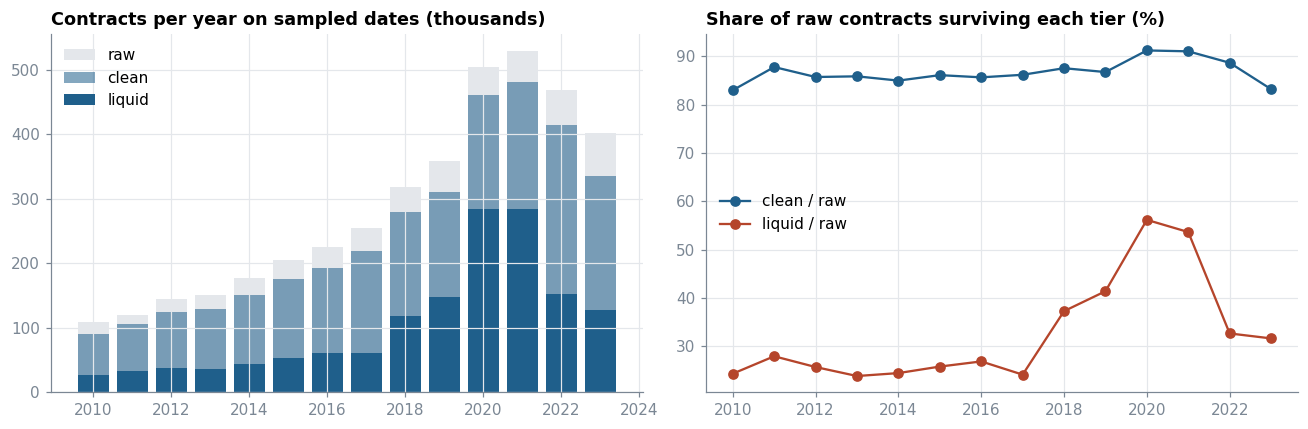

  clean share of raw contracts                            87.5%
  liquid share of raw contracts                           37.0%


In [6]:
def run_funnel(df: pd.DataFrame, rules: list, start: str, tier: str) -> tuple[pd.DataFrame, list]:
    """Apply filters in order; return the surviving rows and a log of (tier, rule, removed, remaining)."""
    log = [(tier, start, 0, len(df))]
    for label, rule in rules:
        drop = rule(df).to_numpy(dtype=bool)
        df = df.loc[~drop]
        log.append((tier, label, int(drop.sum()), len(df)))
    return df, log


base_rules = [
    ("missing strike, spot or DTE", lambda d: d["strike"].isna() | d["spot"].isna() | d["dte"].isna() | (d["strike"] <= 0)),
    ("missing bid or ask", lambda d: d["bid"].isna() | d["ask"].isna()),
    ("zero bid", lambda d: d["bid"] <= 0),
    ("crossed market (bid > ask)", lambda d: d["bid"] > d["ask"]),
    ("duplicate quote (same date, expiry, type, strike)", lambda d: d.duplicated(["date", "expiry", "cp", "strike"])),
    (f"expiry-day noise (DTE < {MIN_DTE})", lambda d: d["dte"] < MIN_DTE),
    (f"out of scope (DTE > {MAX_DTE})", lambda d: d["dte"] > MAX_DTE),
]
clean, log_base = run_funnel(chain, base_rules, "raw contracts on sampled dates", "clean")
clean = clean.copy()
clean["mid"] = 0.5 * (clean["bid"] + clean["ask"])
clean["rel_spread"] = (clean["ask"] - clean["bid"]) / clean["mid"]

liquid_rules = [
    (f"relative spread > {REL_SPREAD_MAX:.0%} of mid", lambda d: d["rel_spread"] > REL_SPREAD_MAX),
    ("zero traded volume", lambda d: ~(d["volume"] > 0)),
]
liquid_rows, log_liq = run_funnel(clean, liquid_rules, "clean contracts", "liquid")
clean["liquid"] = clean.index.isin(liquid_rows.index)
del liquid_rows

audit = pd.DataFrame(log_base + log_liq, columns=["tier", "rule", "rows removed", "rows remaining"])
audit["% of raw remaining"] = (100 * audit["rows remaining"] / len(chain)).map("{:.1f}".format)
audit["rows removed"] = audit["rows removed"].map("{:,}".format)
audit["rows remaining"] = audit["rows remaining"].map("{:,}".format)
display(audit)

by_year = pd.DataFrame({
    "raw": chain.groupby(chain["date"].dt.year).size(),
    "clean": clean.groupby(clean["date"].dt.year).size(),
    "liquid": clean[clean["liquid"]].groupby(clean.loc[clean["liquid"], "date"].dt.year).size(),
}).fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(by_year.index, by_year["raw"] / 1e3, color=GRID, label="raw")
ax[0].bar(by_year.index, by_year["clean"] / 1e3, color=CALL_C, alpha=0.55, label="clean")
ax[0].bar(by_year.index, by_year["liquid"] / 1e3, color=CALL_C, label="liquid")
ax[0].set_title("Contracts per year on sampled dates (thousands)")
ax[0].legend()
ax[1].plot(by_year.index, 100 * by_year["clean"] / by_year["raw"], marker="o", label="clean / raw")
ax[1].plot(by_year.index, 100 * by_year["liquid"] / by_year["raw"], marker="o", label="liquid / raw")
ax[1].set_title("Share of raw contracts surviving each tier (%)")
ax[1].legend()
plt.tight_layout()
plt.show()

finding("clean share of raw contracts", f"{100 * len(clean) / len(chain):.1f}%")
finding("liquid share of raw contracts", f"{100 * clean['liquid'].sum() / len(chain):.1f}%")

In [7]:
removed = sorted(log_base[1:] + log_liq[1:], key=lambda r: -r[2])
liq_y = (by_year["liquid"] / by_year["raw"]).dropna()
box(f"""**What this shows.** Of {len(chain):,} raw contracts on the sampled dates, **{pct(len(clean) / len(chain))} are clean**
(two-sided, uncrossed, 2-730 days) and only **{pct(clean['liquid'].sum() / len(chain))} are liquid**. The largest single cut is
*{removed[0][1]}* ({removed[0][2]:,} rows), then *{removed[1][1]}* ({removed[1][2]:,}). The liquid share was
{pct(liq_y.iloc[0])} in {liq_y.index[0]} and {pct(liq_y.iloc[-1])} in {liq_y.index[-1]}. That gap between the two tiers is
the point of the notebook: most of an option chain is *quoted* but not *traded*, and a quote nobody trades against
is an opinion, not a price.""")

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**What this shows.** Of 3,964,784 raw contracts on the sampled dates, **87% are clean**
(two-sided, uncrossed, 2-730 days) and only **37% are liquid**. The largest single cut is
*zero traded volume* (1,685,983 rows), then *relative spread > 20% of mid* (315,887). The liquid share was
24% in 2010 and 32% in 2023. That gap between the two tiers is
the point of the notebook: most of an option chain is *quoted* but not *traded*, and a quote nobody trades against
is an opinion, not a price.

</div>

### <p style="padding:6px 14px;background-color:#e8f1fb;border-left:6px solid #2c8ae1;margin:0;color:#1f3a5f;font-weight:600">The shape of the market</p>

Before any model, three pictures of what the clean chain actually contains: how many contracts are
listed, where the volume trades, and what it costs to cross the spread. These frame everything that
follows, because the wings, where the arbitrage tests fire most, are also where almost nothing trades.

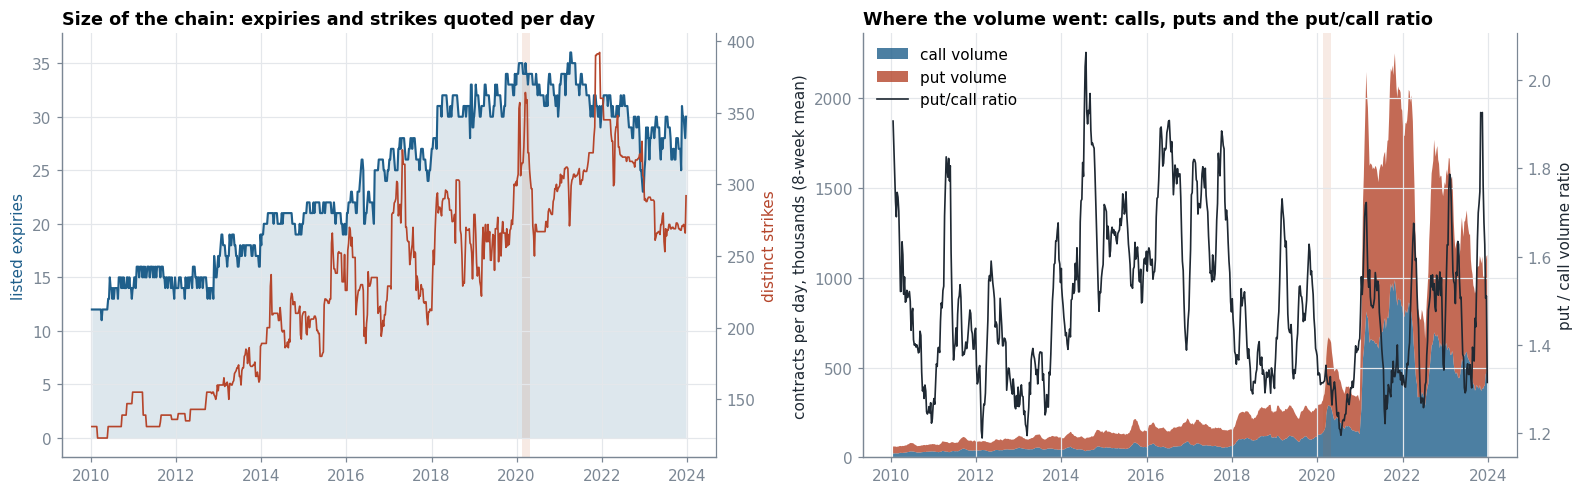

  listed expiries per day, first vs last year             14 -> 28
  median put/call volume ratio                            1.46


In [8]:
eda = clean.assign(m_spot=np.log(clean["strike"] / clean["spot"]))
foot = eda.groupby("date").agg(expiries=("expiry", "nunique"), strikes=("strike", "nunique"))
vol = eda.groupby(["date", "cp"])["volume"].sum().unstack(fill_value=0).sort_index()
roll = vol.rolling(8, min_periods=3).mean()
pc_ratio = (vol["P"] / vol["C"].replace(0, np.nan)).rolling(8, min_periods=3).mean()

fig, ax = plt.subplots(1, 2, figsize=(14.5, 4.6))
a = ax[0]
a.fill_between(foot.index, foot["expiries"], color=CALL_C, alpha=0.15, lw=0)
a.plot(foot.index, foot["expiries"], color=CALL_C, lw=1.4)
a.set_ylabel("listed expiries", color=CALL_C)
b = a.twinx()
b.plot(foot.index, foot["strikes"], color=PUT_C, lw=1.1)
b.set_ylabel("distinct strikes", color=PUT_C)
b.spines["right"].set_visible(True)
b.grid(False)
a.set_title("Size of the chain: expiries and strikes quoted per day")

a = ax[1]
a.stackplot(roll.index, roll["C"] / 1e3, roll["P"] / 1e3, colors=[CALL_C, PUT_C], alpha=0.8,
            labels=["call volume", "put volume"])
a.set_ylabel("contracts per day, thousands (8-week mean)")
b = a.twinx()
b.plot(pc_ratio.index, pc_ratio, color=INK, lw=1.1, label="put/call ratio")
b.set_ylabel("put / call volume ratio")
b.spines["right"].set_visible(True)
b.grid(False)
h1, l1 = a.get_legend_handles_labels()
h2, l2 = b.get_legend_handles_labels()
a.legend(h1 + h2, l1 + l2, loc="upper left")
a.set_title("Where the volume went: calls, puts and the put/call ratio")
for axis in ax:
    shade_stress(axis)
plt.tight_layout()
plt.show()

finding("listed expiries per day, first vs last year",
        f"{foot['expiries'][foot.index.year == foot.index.year.min()].median():.0f} -> "
        f"{foot['expiries'][foot.index.year == foot.index.year.max()].median():.0f}")
finding("median put/call volume ratio", f"{(vol['P'] / vol['C'].replace(0, np.nan)).median():.2f}")

In [9]:
y0, y1 = foot.index.year.min(), foot.index.year.max()
first, last = foot.index.year == y0, foot.index.year == y1
e0, e1 = foot.loc[first, "expiries"].median(), foot.loc[last, "expiries"].median()
s0, s1 = foot.loc[first, "strikes"].median(), foot.loc[last, "strikes"].median()
tot = vol.sum(axis=1)
pcr = vol["P"] / vol["C"].replace(0, np.nan)
in_st = pcr.index.to_series().between(*STRESS_SPAN).to_numpy()
st, rest = pcr[in_st].median(), pcr[~in_st].median()
growth = ("the result of weekly and later daily expiries being listed" if e1 > 1.5 * e0 else "a fairly stable listing schedule")
side = "Puts outnumber calls" if pcr.median() > 1 else "Calls outnumber puts"
box(f"""**What this shows.** The median day in {y0} listed {e0:.0f} expiries and {s0:.0f} distinct strikes, against
{e1:.0f} and {s1:.0f} in {y1}: {growth}. Volume on the sampled dates went from about {tot[tot.index.year == y0].mean() / 1e3:,.0f}k
to {tot[tot.index.year == y1].mean() / 1e3:,.0f}k contracts a day. {side} on a typical day (median put/call ratio {pcr.median():.2f}).
In February-April 2020 the median ratio was {st:.2f} against {rest:.2f} in the rest of the sample.""")

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**What this shows.** The median day in 2010 listed 14 expiries and 131 distinct strikes, against
28 and 270 in 2023: the result of weekly and later daily expiries being listed. Volume on the sampled dates went from about 69k
to 1,208k contracts a day. Puts outnumber calls on a typical day (median put/call ratio 1.46).
In February-April 2020 the median ratio was 1.26 against 1.46 in the rest of the sample.

</div>

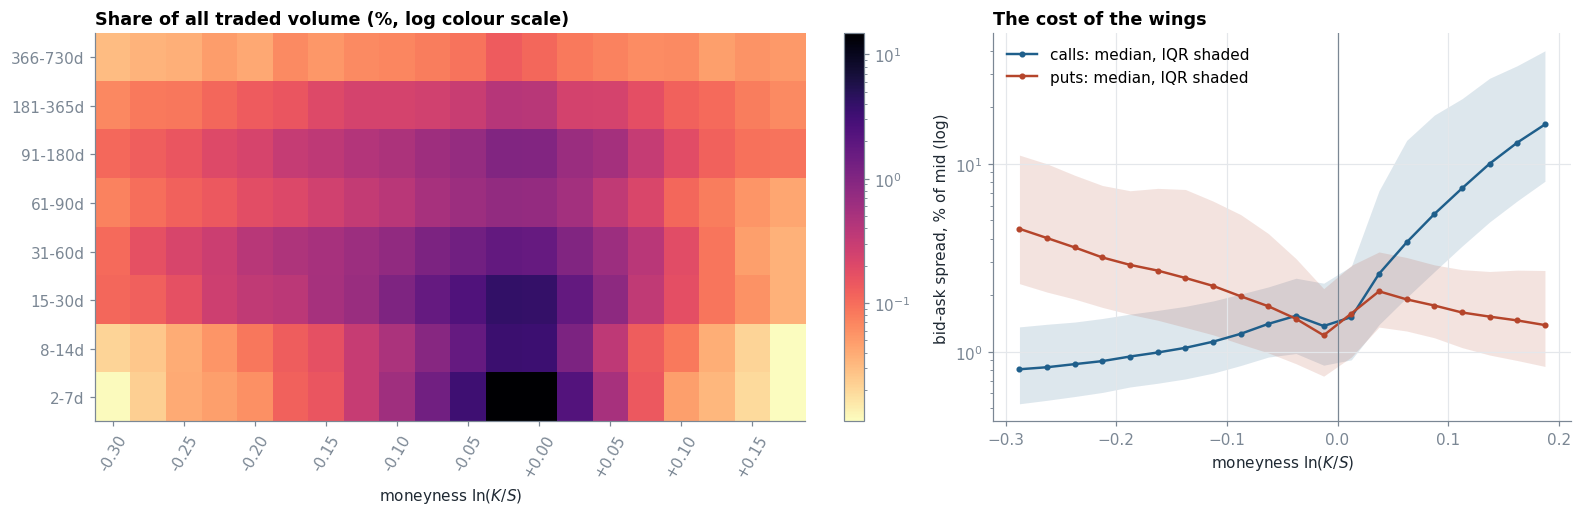

  share of volume within 5% of spot                       67.1%
  median spread: near the money vs k < -0.20 puts         1.6% vs 7.6%


In [10]:
m_edges = np.round(np.arange(-0.30, 0.201, 0.025), 3)
dte_e = [2, 8, 15, 31, 61, 91, 181, 366, 731]
eda["m_bin"] = pd.cut(eda["m_spot"], m_edges)
eda["d_bin"] = pd.cut(eda["dte"], dte_e, right=False)
vol_map = eda.pivot_table(index="d_bin", columns="m_bin", values="volume", aggfunc="sum", observed=False)
share = 100 * vol_map / np.nansum(vol_map.to_numpy())
share_arr = np.where(share.to_numpy() > 0, share.to_numpy(), np.nan)

fig, ax = plt.subplots(1, 2, figsize=(14.5, 4.8), gridspec_kw={"width_ratios": [1.35, 1]})
im = ax[0].imshow(share_arr, aspect="auto", origin="lower", cmap="magma_r",
                  norm=mpl.colors.LogNorm(vmin=max(1e-3, np.nanmin(share_arr)), vmax=np.nanmax(share_arr)))
ax[0].set_xticks(range(0, len(share.columns), 2))
ax[0].set_xticklabels([f"{iv.left:+.2f}" for iv in share.columns[::2]], rotation=60)
ax[0].set_yticks(range(len(share.index)))
ax[0].set_yticklabels([f"{int(iv.left)}-{int(iv.right) - 1}d" for iv in share.index])
ax[0].set_xlabel("moneyness $\\ln(K/S)$")
ax[0].set_title("Share of all traded volume (%, log colour scale)")
ax[0].grid(False)
fig.colorbar(im, ax=ax[0], fraction=0.04)

for side, color, label in (("C", CALL_C, "calls"), ("P", PUT_C, "puts")):
    g = eda[eda["cp"] == side].groupby("m_bin", observed=False)["rel_spread"]
    x = [iv.mid for iv in g.median().index]
    ax[1].fill_between(x, 100 * g.quantile(0.25), 100 * g.quantile(0.75), color=color, alpha=0.15, lw=0)
    ax[1].plot(x, 100 * g.median(), color=color, lw=1.6, marker="o", ms=3, label=f"{label}: median, IQR shaded")
ax[1].set_yscale("log")
ax[1].axvline(0, color=MUTED, lw=0.8)
ax[1].set_xlabel("moneyness $\\ln(K/S)$")
ax[1].set_ylabel("bid-ask spread, % of mid (log)")
ax[1].set_title("The cost of the wings")
ax[1].legend()
plt.tight_layout()
plt.show()

near = eda["m_spot"].abs() < 0.05
finding("share of volume within 5% of spot", f"{100 * eda.loc[near, 'volume'].sum() / eda['volume'].sum():.1f}%")
finding("median spread: near the money vs k < -0.20 puts",
        f"{100 * eda.loc[near, 'rel_spread'].median():.1f}% vs "
        f"{100 * eda.loc[(eda['m_spot'] < -0.20) & (eda['cp'] == 'P'), 'rel_spread'].median():.1f}%")

In [11]:
cell = share.stack().idxmax()
near_share = eda.loc[near, "volume"].sum() / eda["volume"].sum()
sp_near = eda.loc[near, "rel_spread"].median()
sp_wing = eda.loc[(eda["m_spot"] < -0.20) & (eda["cp"] == "P"), "rel_spread"].median()
box(f"""**What this shows.** Trading is concentrated: **{pct(near_share)} of all volume is within 5% of spot**, and the
busiest cell of the map is {cell[0]} days to expiry at moneyness {cell[1]}. The right panel is the other side of the
same coin: the median spread is {100 * sp_near:.1f}% of mid near the money and {100 * sp_wing:.1f}% for puts more than 20%
out of the money, about {sp_wing / sp_near:.0f} times wider. Wide quotes leave room for prices that are inconsistent
with each other without anyone being able to trade on it, which is exactly what section 7 has to separate.""")

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**What this shows.** Trading is concentrated: **67% of all volume is within 5% of spot**, and the
busiest cell of the map is [2, 8) days to expiry at moneyness (0.0, 0.025]. The right panel is the other side of the
same coin: the median spread is 1.6% of mid near the money and 7.6% for puts more than 20%
out of the money, about 5 times wider. Wide quotes leave room for prices that are inconsistent
with each other without anyone being able to trade on it, which is exactly what section 7 has to separate.

</div>

<a id="forwards"></a>
# <p style="padding:10px;background-color:#2c8ae1 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">4. Forwards and discount factors from put-call parity</p>

The file contains no risk-free rate and no dividend yield, and SPY pays a quarterly dividend. For
European options, put-call parity holds exactly:

$$
C(K) - P(K) = D\,(F - K),
$$

where $D$ is the discount factor to expiry and $F$ the forward price of SPY for that expiry. For a fixed
date and expiry this is a straight line in $K$ with slope $-D$ and intercept $D F$, so in principle a
regression of $C - P$ on $K$ gives both the rate and the forward from the chain alone.

**It does not work on SPY, and the reason is instructive.** SPY options are American. An in-the-money
American put is worth more than its European counterpart because it can be exercised early, so $C - P$
falls faster than $D$ per unit of strike on the in-the-money-put side, the fitted slope is steeper than
$-1$, and the implied rate comes out *negative*. The first run of this notebook did exactly that in
every year of the sample (right-hand panel below). An estimate that fails a sanity check this plainly is
a finding, and it is kept in the notebook as one.

So the two quantities are split:

- **Discount factor.** $D = e^{-rT}$ with $r$ from a stated proxy: the annual average 3-month Treasury
  bill yield. It is only used to discount, and a one-point error in $r$ moves a one-year ATM volatility by
  a fraction of a vol point.
- **Forward.** $F = K + (C - P)/D$ at the three strikes closest to spot, median taken. At the money
  $C - P \approx 0$, so $F$ barely depends on $D$, and both options are near the money, where the
  early-exercise premium is smallest.

The forward is preferable to a constant dividend yield $q$: dividends enter only through $F$, the forward
is what the market trades, and it handles lumpy quarterly dividends without a model for them. The
implied carry $q = r - \ln(F/S)/T$ is then the check: it should sit near SPY's dividend yield.

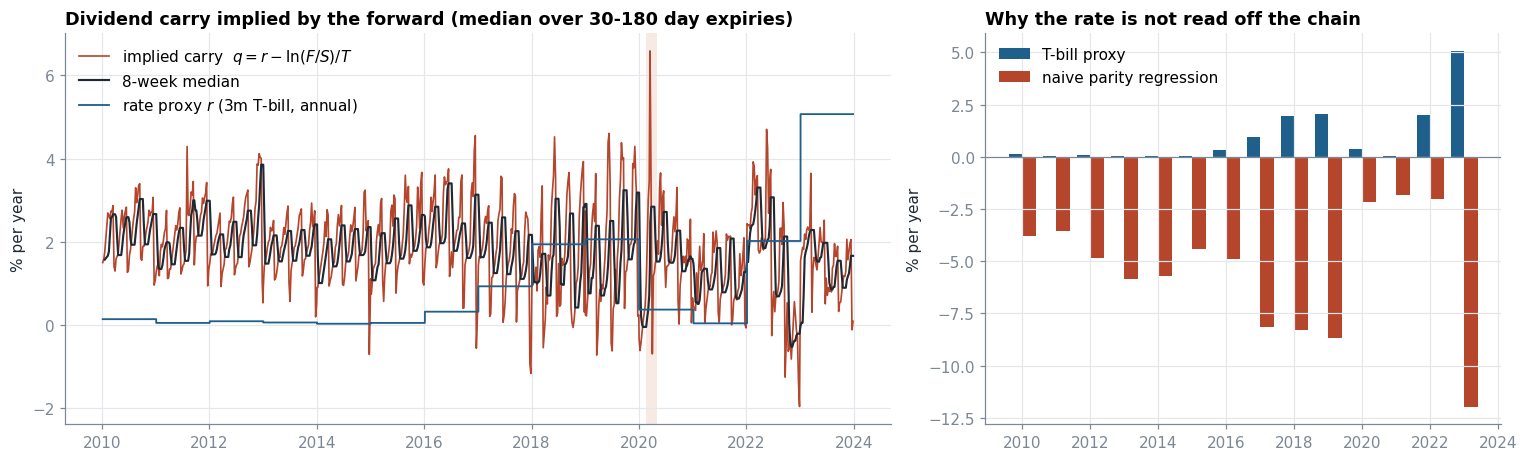

  slices with a forward from parity at the money          100.0%
  median implied dividend carry, whole sample             1.80%
  naive regression rate < 0 in                            14 of 14 years


In [12]:
# Approximate annual averages of the 3-month US Treasury bill yield (FRED series TB3MS), rounded.
# A proxy, stated openly: it is used only to discount, and an error of 1% in r moves a one-year
# ATM option's implied volatility by a fraction of a vol point.
RATE_PROXY = {2010: 0.0014, 2011: 0.0005, 2012: 0.0009, 2013: 0.0006, 2014: 0.0003, 2015: 0.0005,
              2016: 0.0032, 2017: 0.0093, 2018: 0.0194, 2019: 0.0206, 2020: 0.0037, 2021: 0.0004,
              2022: 0.0202, 2023: 0.0507}


def regression_rate_diagnostic(df: pd.DataFrame, window: float = 0.10) -> pd.Series:
    """Median rate implied by regressing C - P on K per slice (30-180 days), by year. Diagnostic only."""
    key = ["date", "expiry"]
    pair = df[df["cp"] == "C"].merge(df[df["cp"] == "P"], on=key + ["strike"], suffixes=("_c", "_p"))
    pair = pair[(np.abs(np.log(pair["strike"] / pair["spot_c"])) <= window) & pair["tau_c"].between(30 / 365, 180 / 365)]
    rows = []
    for (date, _), g in pair.groupby(key):
        if len(g) >= 3:
            slope = np.polyfit(g["strike"], g["mid_c"] - g["mid_p"], 1)[0]
            if slope < 0:
                rows.append((date.year, -np.log(-slope) / g["tau_c"].iat[0]))
    return pd.DataFrame(rows, columns=["year", "r"]).groupby("year")["r"].median()


def implied_forwards(df: pd.DataFrame, n_atm: int = 3) -> pd.DataFrame:
    """Forward F per (date, expiry) from put-call parity at the strikes closest to spot; D from the rate proxy.

    F = K + (C - P) / D. At the money C - P is close to zero, so the estimate barely depends on D,
    and both options are near the money, where the early-exercise premium of an American option is small.
    """
    key = ["date", "expiry"]
    calls = df.loc[df["cp"] == "C", key + ["strike", "mid", "spot", "tau"]]
    puts = df.loc[df["cp"] == "P", key + ["strike", "mid"]]
    pair = calls.merge(puts, on=key + ["strike"], suffixes=("_c", "_p"))
    pair["r"] = pair["date"].dt.year.map(RATE_PROXY).fillna(0.0)
    pair["D"] = np.exp(-pair["r"] * pair["tau"])
    pair["dist"] = (pair["strike"] - pair["spot"]).abs()
    pair = pair.sort_values(key + ["dist"]).groupby(key).head(n_atm)
    pair["F_i"] = pair["strike"] + (pair["mid_c"] - pair["mid_p"]) / pair["D"]
    g = pair.groupby(key).agg(F=("F_i", "median"), n=("F_i", "size"))

    slices = df.groupby(key).agg(spot=("spot", "median"), tau=("tau", "first")).join(g, how="left")
    years = slices.index.get_level_values("date").year
    slices["r_used"] = pd.Series(years, index=slices.index).map(RATE_PROXY).fillna(0.0)
    slices["D"] = np.exp(-slices["r_used"] * slices["tau"])
    ok = (slices["n"] >= 1) & (slices["F"] / slices["spot"]).between(0.8, 1.2)
    slices["q_impl"] = slices["r_used"] - np.log(slices["F"] / slices["spot"]) / slices["tau"]
    q_date = slices.loc[ok & (slices["tau"] >= 30 / 365), "q_impl"].groupby(level="date").median().clip(-0.02, 0.06)
    q_fb = q_date.reindex(slices.index.get_level_values("date")).fillna(0.0).to_numpy()
    fb = (~ok).to_numpy()
    slices.loc[fb, "F"] = (slices["spot"] * np.exp((slices["r_used"] - q_fb) * slices["tau"])).to_numpy()[fb]
    slices["method"] = np.where(ok, "parity at the money", "fallback")
    return slices.reset_index()[key + ["F", "D", "method", "n", "r_used", "q_impl", "tau", "spot"]]


reg_rate = regression_rate_diagnostic(clean[clean["date"].isin(MONTHLY_DATES)])
fwd = implied_forwards(clean)
clean = clean.merge(fwd[["date", "expiry", "F", "D"]], on=["date", "expiry"], how="left")
clean["k"] = np.log(clean["strike"] / clean["F"])
clean["otm"] = ((clean["cp"] == "C") & (clean["strike"] >= clean["F"])) | ((clean["cp"] == "P") & (clean["strike"] < clean["F"]))

good = fwd[(fwd["method"] == "parity at the money") & fwd["tau"].between(30 / 365, 180 / 365)]
carry = good.groupby("date")[["r_used", "q_impl"]].median()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.3), gridspec_kw={"width_ratios": [1.6, 1]})
ax[0].plot(carry.index, 100 * carry["q_impl"], color=PUT_C, lw=1.1, label="implied carry  $q = r - \\ln(F/S)/T$")
ax[0].plot(carry.index, 100 * carry["q_impl"].rolling(8, min_periods=3).median(), color=INK, lw=1.4, label="8-week median")
ax[0].step(carry.index, 100 * carry["r_used"], where="post", color=CALL_C, lw=1.2, label="rate proxy $r$ (3m T-bill, annual)")
shade_stress(ax[0])
ax[0].set_ylabel("% per year")
ax[0].set_title("Dividend carry implied by the forward (median over 30-180 day expiries)")
ax[0].legend(loc="upper left")
yrs = sorted(RATE_PROXY)
ax[1].bar(np.array(yrs) - 0.2, [100 * RATE_PROXY[y] for y in yrs], width=0.4, color=CALL_C, label="T-bill proxy")
ax[1].bar(reg_rate.index + 0.2, 100 * reg_rate.to_numpy(), width=0.4, color=PUT_C, label="naive parity regression")
ax[1].axhline(0, color=MUTED, lw=0.8)
ax[1].set_title("Why the rate is not read off the chain")
ax[1].set_ylabel("% per year")
ax[1].legend()
plt.tight_layout()
plt.show()

finding("slices with a forward from parity at the money", f"{100 * (fwd['method'] == 'parity at the money').mean():.1f}%")
finding("median implied dividend carry, whole sample", f"{100 * carry['q_impl'].median():.2f}%")
finding("naive regression rate < 0 in", f"{int((reg_rate < 0).sum())} of {len(reg_rate)} years")

In [13]:
qy = carry["q_impl"].groupby(carry.index.year).median()
q_med = carry["q_impl"].median()
q_ok = "consistent with" if 0.008 < q_med < 0.025 else "not consistent with"
neg = int((reg_rate < 0).sum())
box(f"""**What this shows.** Parity at the money gave a forward for {pct((fwd['method'] == 'parity at the money').mean())} of all
expiry slices. The dividend carry it implies has a median of {100 * q_med:.2f}% a year (yearly medians from
{100 * qy.min():.2f}% to {100 * qy.max():.2f}%), {q_ok} SPY's usual dividend yield of roughly 1.5-2%; that is the check that the
forwards are right. On the right, the naive regression of $C - P$ on $K$ implies a negative interest rate in {neg} of
{len(reg_rate)} years, including 2023 when Treasury bills paid about 5%: the early-exercise premium of in-the-money American
puts, showing up exactly where theory says it should.""")

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**What this shows.** Parity at the money gave a forward for 100% of all
expiry slices. The dividend carry it implies has a median of 1.80% a year (yearly medians from
0.97% to 2.34%), consistent with SPY's usual dividend yield of roughly 1.5-2%; that is the check that the
forwards are right. On the right, the naive regression of $C - P$ on $K$ implies a negative interest rate in 14 of
14 years, including 2023 when Treasury bills paid about 5%: the early-exercise premium of in-the-money American
puts, showing up exactly where theory says it should.

</div>

<a id="iv"></a>
# <p style="padding:10px;background-color:#2c8ae1 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">5. Implied volatility from scratch</p>

With $F$ and $D$ in hand, the natural pricing formula is Black (1976) on the forward, which is
Black-Scholes with the dividend and the rate absorbed into $F$ and $D$:

$$
C = D\left[F\,N(d_1) - K\,N(d_2)\right], \qquad
P = D\left[K\,N(-d_2) - F\,N(-d_1)\right], \qquad
d_{1,2} = \frac{\ln(F/K) \pm \tfrac12 \sigma^2 T}{\sigma\sqrt{T}} .
$$

There is no closed form for $\sigma$ given a price, so it is solved numerically. Newton-Raphson uses the
derivative of price with respect to volatility, which is vega:

$$
\mathcal{V} = \frac{\partial C}{\partial \sigma} = D\,F\,\varphi(d_1)\sqrt{T},
\qquad
\sigma_{n+1} = \sigma_n - \frac{C(\sigma_n) - C^{\text{mkt}}}{\mathcal{V}(\sigma_n)} .
$$

Newton converges in a handful of steps near the money, but vega collapses in the wings and at short
maturities, and a tiny vega turns a small pricing error into an enormous step. Any contract whose Newton
step leaves $[10^{-4}, 5]$, or whose vega is effectively zero, is handed to bisection, which is slow
but cannot diverge because price is monotone in $\sigma$. A price outside the no-arbitrage bounds
$D\,(F-K)^+ < C < D F$ has no implied volatility at all, and is counted rather than forced.

Everything is vectorised: each Newton step updates all unconverged contracts at once. Prices are
**mid** quotes throughout this section.

In [14]:
SQRT_2PI = np.sqrt(2.0 * np.pi)


def black_price(F: np.ndarray, K: np.ndarray, tau: np.ndarray, D: np.ndarray,
                sigma: np.ndarray, is_call: np.ndarray) -> np.ndarray:
    """Black (1976) price of a European option on the forward F, discounted by D."""
    v = sigma * np.sqrt(tau)
    d1 = (np.log(F / K) + 0.5 * v * v) / v
    d2 = d1 - v
    call = D * (F * ndtr(d1) - K * ndtr(d2))
    put = D * (K * ndtr(-d2) - F * ndtr(-d1))
    return np.where(is_call, call, put)


def black_vega(F: np.ndarray, K: np.ndarray, tau: np.ndarray, D: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    """dPrice/dSigma under Black (1976); identical for calls and puts."""
    v = sigma * np.sqrt(tau)
    d1 = (np.log(F / K) + 0.5 * v * v) / v
    return D * F * np.exp(-0.5 * d1 * d1) / SQRT_2PI * np.sqrt(tau)


@dataclass
class IVResult:
    """Implied volatilities plus solver diagnostics for each contract."""
    iv: np.ndarray            # NaN where no solution exists
    method: np.ndarray        # 'newton', 'bisection', 'no solution', 'not converged'
    newton_steps: np.ndarray  # Newton iterations used


def implied_vol(price: np.ndarray, F: np.ndarray, K: np.ndarray, tau: np.ndarray, D: np.ndarray,
                is_call: np.ndarray, tol: float = 1e-6, max_newton: int = 40,
                n_bisect: int = 60, lo: float = 1e-4, hi: float = 5.0) -> IVResult:
    """Vectorised implied volatility: Newton-Raphson on vega, with a bisection fallback.

    tol is an absolute price tolerance in dollars. Contracts whose price violates the
    no-arbitrage bounds are returned as NaN with method 'no solution'.
    """
    n = price.size
    intrinsic = D * np.maximum(np.where(is_call, F - K, K - F), 0.0)
    upper = np.where(is_call, D * F, D * K)
    valid = np.isfinite(price) & np.isfinite(F) & np.isfinite(D) & (tau > 0) & (price > intrinsic) & (price < upper)

    x = np.clip(np.sqrt(2 * np.pi / np.maximum(tau, 1e-8)) * price / (D * F), 0.05, 1.5)
    steps = np.zeros(n, dtype=np.int16)
    done = np.zeros(n, dtype=bool)
    to_bisect = np.zeros(n, dtype=bool)
    live = valid.copy()
    for _ in range(max_newton):
        idx = np.flatnonzero(live)
        if idx.size == 0:
            break
        diff = black_price(F[idx], K[idx], tau[idx], D[idx], x[idx], is_call[idx]) - price[idx]
        hit = np.abs(diff) < tol
        done[idx[hit]] = True
        vega = black_vega(F[idx], K[idx], tau[idx], D[idx], x[idx])
        with np.errstate(divide="ignore", invalid="ignore"):
            new = x[idx] - diff / vega
        bad = ~hit & ((vega < 1e-8) | ~np.isfinite(new) | (new <= lo) | (new >= hi))
        step = ~hit & ~bad
        x[idx[step]] = new[step]
        steps[idx[~hit]] += 1
        to_bisect[idx[bad]] = True
        live[idx[hit | bad]] = False
    to_bisect |= valid & ~done & ~to_bisect

    idx = np.flatnonzero(to_bisect)
    if idx.size:
        a = np.full(idx.size, lo)
        b = np.full(idx.size, hi)
        for _ in range(n_bisect):
            mid = 0.5 * (a + b)
            above = black_price(F[idx], K[idx], tau[idx], D[idx], mid, is_call[idx]) > price[idx]
            b = np.where(above, mid, b)
            a = np.where(above, a, mid)
        sol = 0.5 * (a + b)
        err = np.abs(black_price(F[idx], K[idx], tau[idx], D[idx], sol, is_call[idx]) - price[idx])
        x[idx] = sol
        done[idx] = err < 10 * tol

    iv = np.where(valid & done, x, np.nan)
    method = np.where(~valid, "no solution",
                      np.where(~done, "not converged", np.where(to_bisect, "bisection", "newton")))
    return IVResult(iv=iv, method=method, newton_steps=steps)


t = time.time()
res = implied_vol(clean["mid"].to_numpy(), clean["F"].to_numpy(), clean["strike"].to_numpy(),
                  clean["tau"].to_numpy(), clean["D"].to_numpy(), (clean["cp"] == "C").to_numpy())
clean["iv"] = res.iv
clean["iv_method"] = res.method
elapsed = time.time() - t

summary = (pd.Series(res.method).value_counts().rename("contracts").to_frame()
           .assign(share=lambda d: 100 * d["contracts"] / d["contracts"].sum()))
display(summary)
newton_ok = res.method == "newton"
finding("contracts solved", f"{len(clean):,} in {elapsed:.1f}s")
finding("mean Newton iterations (Newton-converged)", f"{res.newton_steps[newton_ok].mean():.2f}")
finding("share needing bisection", f"{100 * (res.method == 'bisection').mean():.2f}%")

,contracts,share
newton,2374523,68.471081
bisection,1005541,28.995499
no solution,86360,2.490253
not converged,1497,0.043167


  contracts solved                                        3,467,921 in 11.3s
  mean Newton iterations (Newton-converged)               4.12
  share needing bisection                                 29.00%


### <p style="padding:6px 14px;background-color:#e8f1fb;border-left:6px solid #2c8ae1;margin:0;color:#1f3a5f;font-weight:600">My implied volatility against the vendor's</p>

The file ships its own `C_IV` / `P_IV`. The vendor's method is not documented: the rate, dividend
treatment, time convention and whether an American model was used are all unknown. So the comparison
below can locate *where* the two disagree, but the explanations offered for *why* are hypotheses about
the vendor's choices, not facts about them.

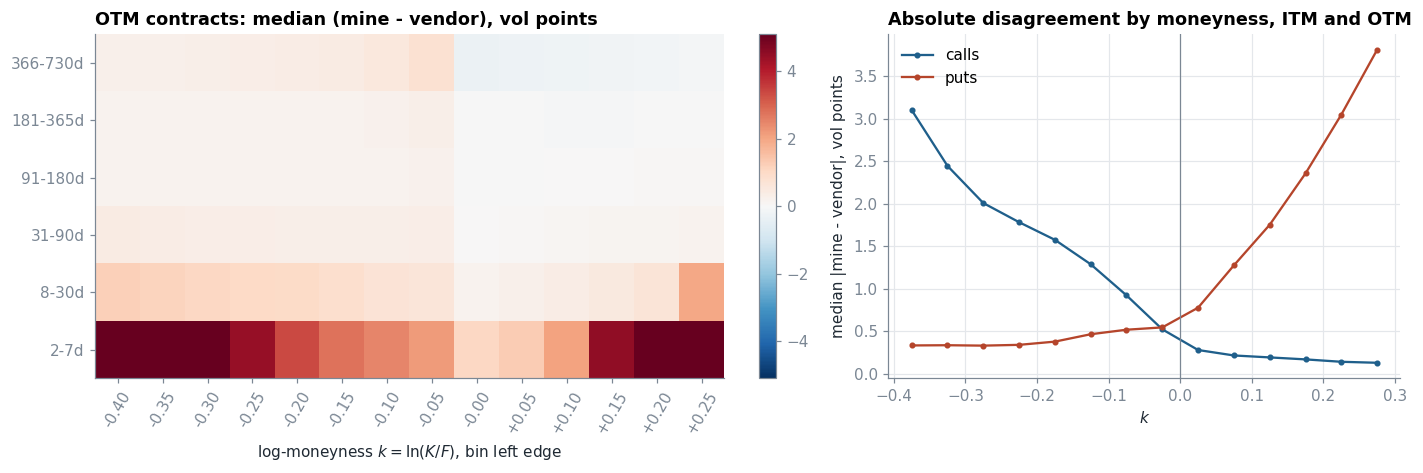

  median |diff| near the money (|k| < 0.02)               0.42 vol pts
  median |diff| far OTM puts (k < -0.20)                  0.30 vol pts
  median diff ITM puts (k > 0.10), signed                 +1.52 vol pts


In [15]:
cmp = clean[np.isfinite(clean["iv"]) & np.isfinite(clean["iv_vendor"]) & (clean["iv_vendor"] > 0)].copy()
cmp["diff_vp"] = 100 * (cmp["iv"] - cmp["iv_vendor"])          # vol points
k_edges = np.round(np.arange(-0.40, 0.301, 0.05), 2)
dte_edges = [2, 8, 31, 91, 181, 366, 731]
cmp["k_bin"] = pd.cut(cmp["k"], k_edges)
cmp["dte_bin"] = pd.cut(cmp["dte"], dte_edges, right=False)

otm_cmp = cmp[cmp["otm"]]
heat = otm_cmp.pivot_table(index="dte_bin", columns="k_bin", values="diff_vp", aggfunc="median", observed=False)
lim = np.nanpercentile(np.abs(heat.to_numpy()), 95) if np.isfinite(heat.to_numpy()).any() else 1.0

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.35, 1]})
im = ax[0].imshow(heat.to_numpy(), aspect="auto", cmap="RdBu_r", norm=TwoSlopeNorm(0, -lim, lim), origin="lower")
ax[0].set_xticks(range(len(heat.columns)))
ax[0].set_xticklabels([f"{iv.left:+.2f}" for iv in heat.columns], rotation=60)
ax[0].set_yticks(range(len(heat.index)))
ax[0].set_yticklabels([f"{int(iv.left)}-{int(iv.right) - 1}d" for iv in heat.index])
ax[0].set_xlabel("log-moneyness $k = \\ln(K/F)$, bin left edge")
ax[0].set_title("OTM contracts: median (mine - vendor), vol points")
ax[0].grid(False)
fig.colorbar(im, ax=ax[0], fraction=0.04)

for side, color, label in (("C", CALL_C, "calls"), ("P", PUT_C, "puts")):
    s = cmp[cmp["cp"] == side].groupby("k_bin", observed=False)["diff_vp"].apply(lambda x: np.median(np.abs(x)))
    ax[1].plot([iv.mid for iv in s.index], s.to_numpy(), marker="o", ms=3, color=color, label=label)
ax[1].axvline(0, color=MUTED, lw=0.8)
ax[1].set_xlabel("$k$")
ax[1].set_ylabel("median |mine - vendor|, vol points")
ax[1].set_title("Absolute disagreement by moneyness, ITM and OTM")
ax[1].legend()
plt.tight_layout()
plt.show()

atm = otm_cmp[otm_cmp["k"].abs() < 0.02]
wing = otm_cmp[otm_cmp["k"] < -0.20]
itm_put = cmp[(cmp["cp"] == "P") & (cmp["k"] > 0.10)]
finding("median |diff| near the money (|k| < 0.02)", f"{np.median(np.abs(atm['diff_vp'])):.2f} vol pts")
finding("median |diff| far OTM puts (k < -0.20)", f"{np.median(np.abs(wing['diff_vp'])):.2f} vol pts")
finding("median diff ITM puts (k > 0.10), signed", f"{np.median(itm_put['diff_vp']):+.2f} vol pts" if len(itm_put) else "n/a")

In [16]:
a = np.median(np.abs(atm["diff_vp"]))
w_ = np.median(np.abs(wing["diff_vp"]))
ip = np.median(itm_put["diff_vp"]) if len(itm_put) else np.nan
if ip > 0.25:
    why = ("A positive gap on in-the-money puts is what an American pricing model on the vendor's side would produce: "
           "Black's formula reads the early-exercise premium as extra volatility, an American model does not.")
elif ip < -0.25:
    why = "A negative gap there points to a different forward or rate assumption rather than to early exercise."
else:
    why = "That gap is small, so any early-exercise treatment on the vendor's side makes little difference on this sample."
box(f"""**What this shows.** Near the money the two estimates agree to within {a:.2f} vol points (median absolute
difference). The disagreement is {w_:.2f} points on puts more than 20% out of the money, where vega is small and a
one-cent difference in the price used moves the implied volatility a lot. On in-the-money puts the signed median gap
is {ip:+.2f} points. {why} The vendor's method is undocumented, so these are hypotheses, not findings about it.""")

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**What this shows.** Near the money the two estimates agree to within 0.42 vol points (median absolute
difference). The disagreement is 0.30 points on puts more than 20% out of the money, where vega is small and a
one-cent difference in the price used moves the implied volatility a lot. On in-the-money puts the signed median gap
is +1.52 points. A positive gap on in-the-money puts is what an American pricing model on the vendor's side would produce: Black's formula reads the early-exercise premium as extra volatility, an American model does not. The vendor's method is undocumented, so these are hypotheses, not findings about it.

</div>

<a id="surface"></a>
# <p style="padding:10px;background-color:#2c8ae1 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">6. The volatility surface</p>

From here on, volatilities come from **out-of-the-money** contracts only: puts below the forward, calls
above it. This is standard desk practice and it matters more than usual here, because SPY options are
American. An in-the-money American put carries an early-exercise premium that Black's formula reads as
extra volatility; the out-of-the-money contract at the same strike carries almost none.

Total implied variance $w(k, T) = \sigma^2(k, T)\,T$ at log-moneyness $k = \ln(K/F)$ is the natural
coordinate for everything that follows, because the calendar condition and SVI are both stated in it.

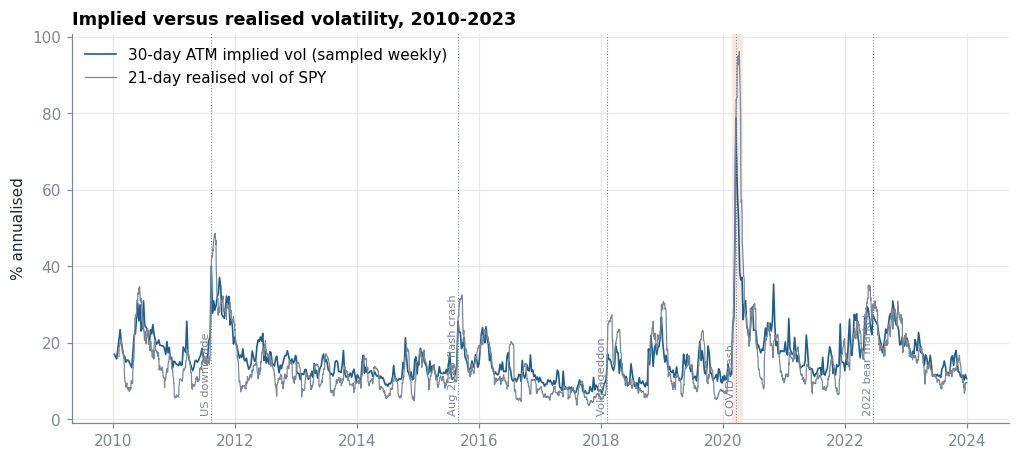

  mean 30d implied minus 21d realised                     +1.09 vol pts
  share of weeks with implied above realised              69.0%
  peak 30d ATM implied vol (date)                         78.7% (2020-03-16)


In [17]:
surf = clean[clean["otm"] & np.isfinite(clean["iv"]) & clean["dte"].between(7, MAX_DTE)].copy()
surf["w"] = surf["iv"] ** 2 * surf["tau"]


def atm_by_slice(d: pd.DataFrame) -> pd.DataFrame:
    """ATM implied vol per (date, expiry), linearly interpolated at k = 0 from OTM quotes."""
    rows = []
    for (date, expiry), g in d.sort_values("k").groupby(["date", "expiry"], sort=False):
        k, v = g["k"].to_numpy(), g["iv"].to_numpy()
        if len(k) >= 2 and k[0] <= 0 <= k[-1]:
            rows.append((date, expiry, g["tau"].iat[0], g["dte"].iat[0], float(np.interp(0.0, k, v))))
    return pd.DataFrame(rows, columns=["date", "expiry", "tau", "dte", "atm_iv"])


def interp_atm_at(atm: pd.DataFrame, days: float) -> pd.Series:
    """Constant-maturity ATM vol: interpolate total variance across expiries at a fixed horizon."""
    target = days / 365.0
    out = {}
    for date, g in atm.sort_values("tau").groupby("date"):
        tau, w = g["tau"].to_numpy(), (g["atm_iv"] ** 2 * g["tau"]).to_numpy()
        if tau[0] <= target <= tau[-1]:
            out[date] = np.sqrt(np.interp(target, tau, w) / target)
    return pd.Series(out, name=f"atm_{int(days)}d")


atm = atm_by_slice(surf)
atm30 = interp_atm_at(atm, 30)
spot_daily["rv21"] = np.log(spot_daily["spot"]).diff().rolling(21).std() * np.sqrt(252)
rv = spot_daily.set_index("date")["rv21"]

fig, ax = plt.subplots()
ax.plot(atm30.index, 100 * atm30, color=CALL_C, lw=1.1, label="30-day ATM implied vol (sampled weekly)")
ax.plot(rv.index, 100 * rv, color=MUTED, lw=0.8, label="21-day realised vol of SPY")
shade_stress(ax)
mark_events(ax)
ax.set_ylabel("% annualised")
ax.set_title("Implied versus realised volatility, 2010-2023")
ax.legend(loc="upper left")
plt.show()

vrp = (atm30 - rv.reindex(atm30.index)).dropna()
finding("mean 30d implied minus 21d realised", f"{100 * vrp.mean():+.2f} vol pts")
finding("share of weeks with implied above realised", f"{100 * (vrp > 0).mean():.1f}%")
finding("peak 30d ATM implied vol (date)", f"{100 * atm30.max():.1f}% ({atm30.idxmax().date()})")

In [18]:
lead = ("Implied volatility sat above the realised volatility of the previous month" if vrp.mean() > 0
        else "Implied volatility sat below the realised volatility of the previous month on average")
box(f"""**What this shows.** {lead}: the mean gap over {len(vrp)} sampled weeks is {100 * vrp.mean():+.1f} vol points, and
implied was the higher of the two {pct((vrp > 0).mean())} of the time. A positive gap is the volatility risk premium,
the compensation option sellers receive for carrying crash risk. It turns negative in bursts, when realised volatility
jumps faster than the market reprices. The highest 30-day implied level in the sample, {100 * atm30.max():.0f}%, was on
{atm30.idxmax().date()}.""")

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**What this shows.** Implied volatility sat above the realised volatility of the previous month: the mean gap over 719 sampled weeks is +1.1 vol points, and
implied was the higher of the two 69% of the time. A positive gap is the volatility risk premium,
the compensation option sellers receive for carrying crash risk. It turns negative in bursts, when realised volatility
jumps faster than the market reprices. The highest 30-day implied level in the sample, 79%, was on
2020-03-16.

</div>

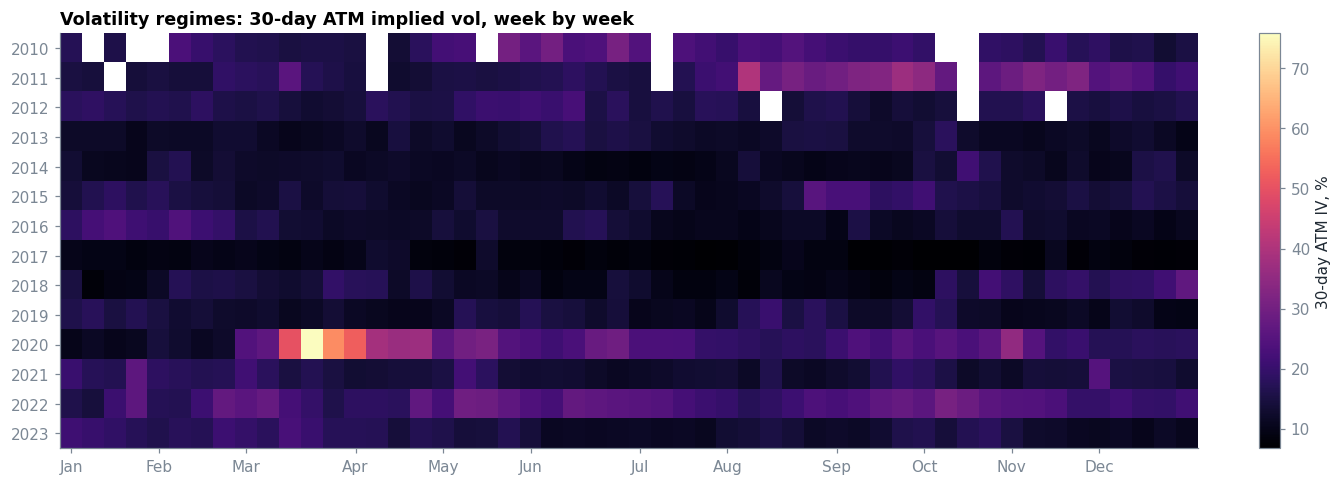

  calmest year (median 30d ATM IV)                        2017 (8.5%)
  most turbulent year (median 30d ATM IV)                 2020 (23.1%)


In [19]:
cal = atm30.to_frame("iv")
cal["year"] = cal.index.year
cal["week"] = np.minimum(cal.index.isocalendar().week.to_numpy(), 52)
regime = cal.pivot_table(index="year", columns="week", values="iv", aggfunc="mean")

fig, ax = plt.subplots(figsize=(14.5, 4.9))
im = ax.imshow(100 * regime.to_numpy(), aspect="auto", cmap="magma", interpolation="nearest")
ax.set_yticks(range(len(regime.index)))
ax.set_yticklabels(regime.index)
month_weeks = [1, 5, 9, 14, 18, 22, 27, 31, 36, 40, 44, 48]
ax.set_xticks([regime.columns.get_indexer([w], method="nearest")[0] for w in month_weeks])
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.grid(False)
ax.set_title("Volatility regimes: 30-day ATM implied vol, week by week")
fig.colorbar(im, ax=ax, fraction=0.03, label="30-day ATM IV, %")
plt.show()

yearly = cal.groupby("year")["iv"].agg(["median", "max"])
finding("calmest year (median 30d ATM IV)", f"{yearly['median'].idxmin()} ({100 * yearly['median'].min():.1f}%)")
finding("most turbulent year (median 30d ATM IV)", f"{yearly['median'].idxmax()} ({100 * yearly['median'].max():.1f}%)")

In [20]:
box(f"""**What this shows.** Each row is a year and each cell a week. The calmest year by median 30-day implied
volatility was {yearly['median'].idxmin()} ({100 * yearly['median'].min():.1f}%), the most turbulent {yearly['median'].idxmax()}
({100 * yearly['median'].max():.1f}%); the single highest week of each year ranges from {100 * yearly['max'].min():.0f}% to
{100 * yearly['max'].max():.0f}%. Read across a row to see how long a stress episode lasted, and down a column to compare
the same season across years.""")

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**What this shows.** Each row is a year and each cell a week. The calmest year by median 30-day implied
volatility was 2017 (8.5%), the most turbulent 2020
(23.1%); the single highest week of each year ranges from 13% to
79%. Read across a row to see how long a stress episode lasted, and down a column to compare
the same season across years.

</div>

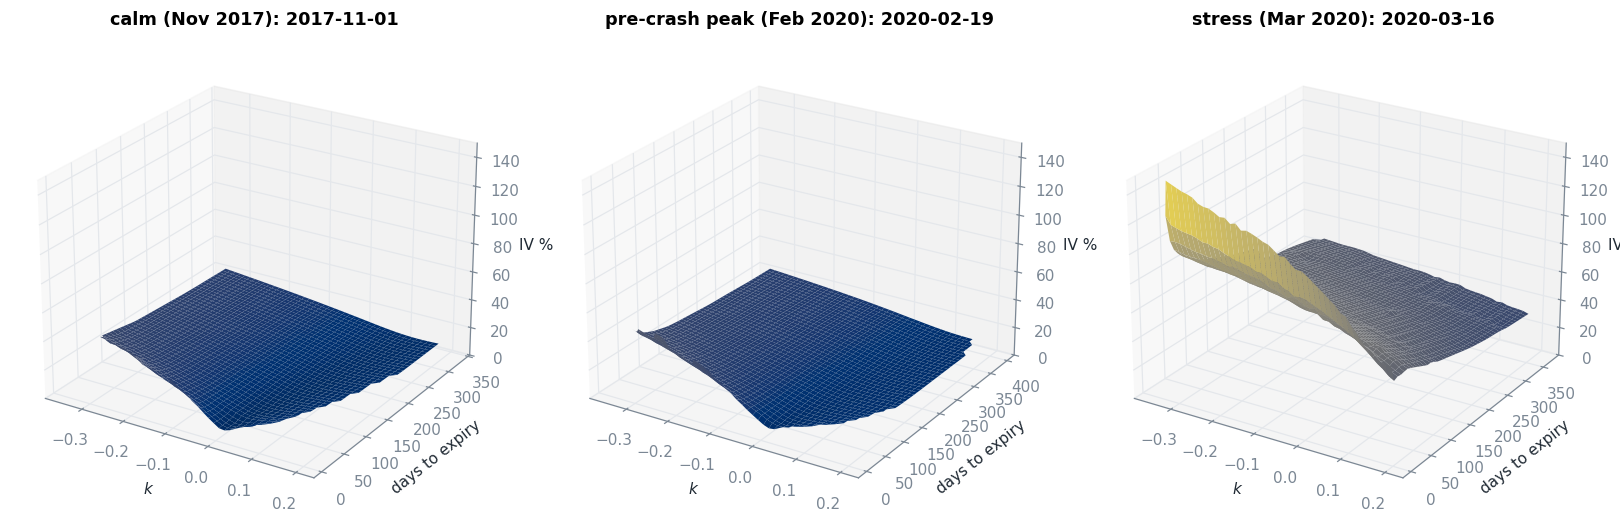

In [21]:
fig = plt.figure(figsize=(15, 4.8))
zmax = 0
grids = {}
for name, d in EVENT_DATES.items():
    p = surf[(surf["date"] == d) & surf["k"].between(-0.35, 0.20) & (surf["dte"] <= 400)]
    kg, tg = np.meshgrid(np.linspace(-0.35, 0.20, 45), np.linspace(p["tau"].min(), p["tau"].max(), 45))
    zg = griddata((p["k"], p["tau"]), 100 * p["iv"], (kg, tg), method="linear")
    grids[name] = (kg, tg, zg)
    zmax = max(zmax, np.nanmax(zg))
for i, (name, (kg, tg, zg)) in enumerate(grids.items(), start=1):
    ax = fig.add_subplot(1, 3, i, projection="3d")
    ax.plot_surface(kg, 365 * tg, zg, cmap="cividis", vmin=0, vmax=zmax, linewidth=0, antialiased=True)
    ax.set_zlim(0, zmax)
    ax.set_xlabel("$k$")
    ax.set_ylabel("days to expiry")
    ax.set_zlabel("IV %")
    ax.set_title(f"{name}: {EVENT_DATES[name].date()}", loc="center")
    ax.view_init(elev=24, azim=-58)
plt.tight_layout()
plt.show()

In [22]:
lines = []
for name, d in EVENT_DATES.items():
    g = atm[atm["date"] == d].sort_values("dte")
    lvl = np.interp(30, g["dte"], g["atm_iv"]) if len(g) >= 2 else np.nan
    day = surf[surf["date"] == d]
    exp = day.groupby("expiry")["dte"].first()
    sl = day[day["expiry"] == exp.index[np.argmin(np.abs(exp.to_numpy() - 30))]].sort_values("k") if len(exp) else day
    skew = np.interp(-0.10, sl["k"], sl["iv"]) - np.interp(0.0, sl["k"], sl["iv"]) if len(sl) >= 3 else np.nan
    lines.append(f"- **{name}** ({d.date()}): 30-day ATM vol {100 * lvl:.1f}%, and a put 10% below the forward "
                 f"priced {100 * skew:+.1f} vol points above ATM.")
box("**What this shows.** The three surfaces share one vertical scale, so height is directly comparable.\n\n"
    + "\n".join(lines) + "\n\nComparing the two numbers across dates separates a change in the *level* of volatility "
    "from a change in its *shape*; a single volatility number would hide the second.")

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**What this shows.** The three surfaces share one vertical scale, so height is directly comparable.

- **calm (Nov 2017)** (2017-11-01): 30-day ATM vol 7.6%, and a put 10% below the forward priced +11.2 vol points above ATM.
- **pre-crash peak (Feb 2020)** (2020-02-19): 30-day ATM vol 12.3%, and a put 10% below the forward priced +10.1 vol points above ATM.
- **stress (Mar 2020)** (2020-03-16): 30-day ATM vol 78.7%, and a put 10% below the forward priced +7.2 vol points above ATM.

Comparing the two numbers across dates separates a change in the *level* of volatility from a change in its *shape*; a single volatility number would hide the second.

</div>

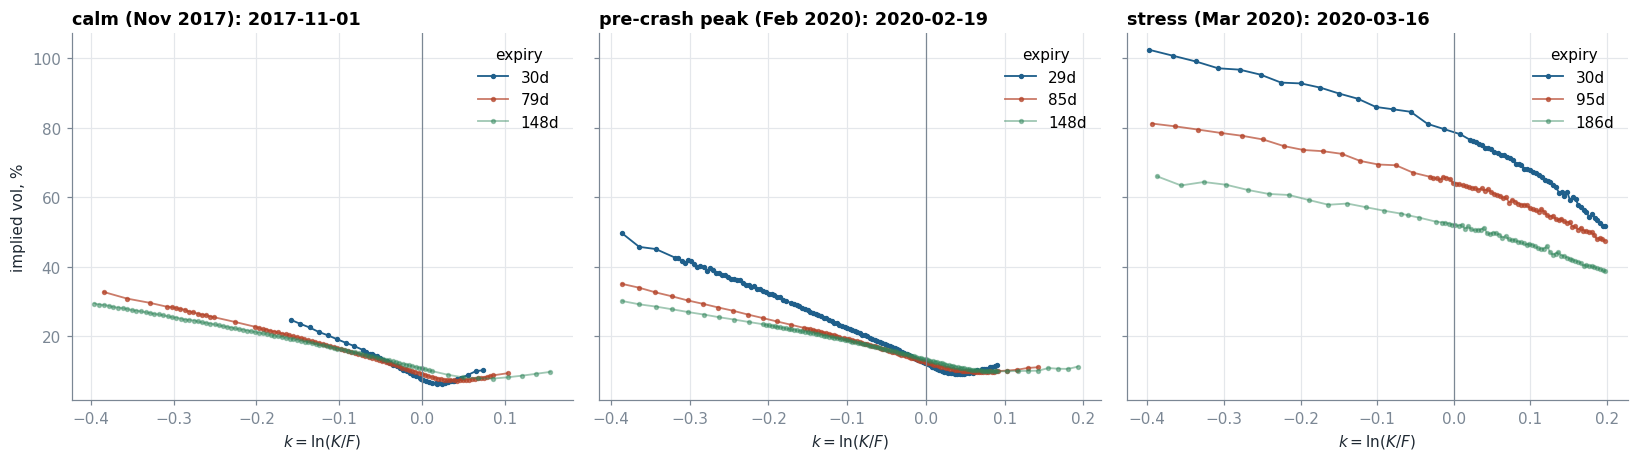

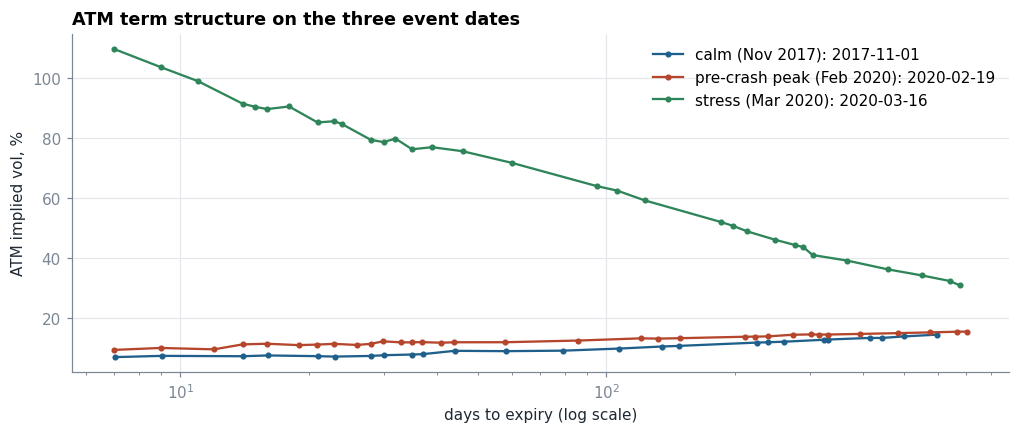

In [23]:
def nearest_expiries(d: pd.DataFrame, targets=(30, 90, 180)) -> list:
    """For one quote date, the expiry closest to each target DTE."""
    exp = d.groupby("expiry")["dte"].first()
    return [exp.index[np.argmin(np.abs(exp.to_numpy() - t))] for t in targets]


fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
for ax, (name, d) in zip(axes, EVENT_DATES.items()):
    day = surf[(surf["date"] == d) & surf["k"].between(-0.40, 0.20)]
    for expiry, shade in zip(nearest_expiries(day), (1.0, 0.7, 0.45)):
        g = day[day["expiry"] == expiry].sort_values("k")
        ax.plot(g["k"], 100 * g["iv"], marker="o", ms=2.5, lw=1.2, alpha=shade,
                label=f"{int(g['dte'].iat[0])}d")
    ax.axvline(0, color=MUTED, lw=0.8)
    ax.set_title(f"{name}: {d.date()}")
    ax.set_xlabel("$k = \\ln(K/F)$")
    ax.legend(title="expiry")
axes[0].set_ylabel("implied vol, %")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
for name, d in EVENT_DATES.items():
    g = atm[atm["date"] == d].sort_values("dte")
    ax.plot(g["dte"], 100 * g["atm_iv"], marker="o", ms=3, label=f"{name}: {d.date()}")
ax.set_xscale("log")
ax.set_xlabel("days to expiry (log scale)")
ax.set_ylabel("ATM implied vol, %")
ax.set_title("ATM term structure on the three event dates")
ax.legend()
plt.show()

In [24]:
lines, skewed, checked = [], 0, 0
for name, d in EVENT_DATES.items():
    g = atm[atm["date"] == d].sort_values("dte")
    day = surf[surf["date"] == d]
    for expiry, sl in day.sort_values("k").groupby("expiry"):
        if sl["k"].min() <= -0.05 and sl["k"].max() >= 0.05:
            checked += 1
            skewed += np.interp(-0.05, sl["k"], sl["iv"]) > np.interp(0.05, sl["k"], sl["iv"])
    if len(g) >= 2:
        s, l = g.iloc[0], g.iloc[-1]
        shape = "upward sloping (contango)" if l["atm_iv"] > s["atm_iv"] else "inverted (backwardation)"
        lines.append(f"- **{name}**: {shape}, {100 * s['atm_iv']:.1f}% at {int(s['dte'])} days against "
                     f"{100 * l['atm_iv']:.1f}% at {int(l['dte'])} days.")
box(f"**What this shows.** On these three dates, {skewed} of {checked} expiries price a put 5% below the forward at a "
    "higher volatility than a call 5% above it: the skew, the market's price for protection against a fall. "
    "The term structure tells the regime:\n\n" + "\n".join(lines) + "\n\nIn quiet markets long-dated options usually "
    "carry more variance; when the short end sits above the long end, the market expects current turbulence to fade.")

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**What this shows.** On these three dates, 84 of 84 expiries price a put 5% below the forward at a higher volatility than a call 5% above it: the skew, the market's price for protection against a fall. The term structure tells the regime:

- **calm (Nov 2017)**: upward sloping (contango), 7.0% at 7 days against 14.5% at 597 days.
- **pre-crash peak (Feb 2020)**: upward sloping (contango), 9.4% at 7 days against 15.5% at 702 days.
- **stress (Mar 2020)**: inverted (backwardation), 109.7% at 7 days against 30.9% at 676 days.

In quiet markets long-dated options usually carry more variance; when the short end sits above the long end, the market expects current turbulence to fade.

</div>

<a id="arb"></a>
# <p style="padding:10px;background-color:#2c8ae1 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">7. Static arbitrage detection</p>

These are the conditions any set of European option prices must satisfy, with no assumption about
how the underlying moves. Each is a portfolio whose payoff is never negative; if its price is negative,
someone is paying you to hold it.

**Vertical spreads.** For strikes $K_1 < K_2$:

$$
0 \;\le\; C(K_1) - C(K_2) \;\le\; K_2 - K_1, \qquad
0 \;\le\; P(K_2) - P(K_1) \;\le\; K_2 - K_1.
$$

The left inequality is monotonicity (a call with a lower strike is worth more); the right one bounds the
spread by its maximum payoff. For European options the tighter bound $D\,(K_2 - K_1)$ holds, but SPY
options are American and a deep in-the-money put can be exercised today for the full strike difference,
so only the undiscounted bound is a genuine arbitrage condition here.

**Butterflies (convexity in strike).** The textbook form $C(K-\Delta K) - 2C(K) + C(K+\Delta K) \ge 0$
assumes equally spaced strikes, which SPY's chain does not have: spacing changes between the centre and
the wings. The general form for $K_1 < K_2 < K_3$ with $\lambda = \frac{K_3 - K_2}{K_3 - K_1}$ is

$$
\lambda\,C(K_1) + (1-\lambda)\,C(K_3) - C(K_2) \;\ge\; 0 ,
$$

and the same for puts. Scaled by $K_3 - K_1$ it is a portfolio of whole contracts.

**Calendar.** At fixed log-moneyness $k = \ln(K/F)$, total implied variance cannot fall with maturity:

$$
\frac{\partial\, w(k, T)}{\partial T} \;\ge\; 0, \qquad w = \sigma^2 T .
$$

This one is tested in total-variance space on out-of-the-money quotes, interpolating each expiry onto a
common grid of $k$ (the other two are tested directly on prices). A crossing is counted only if the
longer expiry's variance is more than 1% below the shorter one's.

### <p style="padding:6px 14px;background-color:#e8f1fb;border-left:6px solid #2c8ae1;margin:0;color:#1f3a5f;font-weight:600">Mid prices versus executable prices</p>

A violation at mid prices is only a statement about a number the vendor computed. The question a desk
asks is whether the portfolio can be put on at quoted prices: **buy at the ask, sell at the bid**. For a
butterfly that means

$$
\lambda\,C^{\text{ask}}(K_1) + (1-\lambda)\,C^{\text{ask}}(K_3) - C^{\text{bid}}(K_2) < 0 ,
$$

and analogously for verticals. Every test below is therefore run twice: at mid (*mid violation*) and at
executable prices (*tradable violation*), on the clean universe and then again on liquid contracts only.
The headline tests use **out-of-the-money contracts**, the same universe the surface is built from.
Deep in-the-money options are rarely traded, their end-of-day quotes are often stale, and for American
puts the price includes an early-exercise premium. They are tested separately and shown as a comparison,
so the difference between the two universes is visible rather than averaged away.

Violations smaller than one cent, the minimum quote increment, are treated as rounding. Duplicate quotes
(the same contract listed twice on a date) were already removed in the audit; left in, a pair of identical
strikes with different quotes looks like an arbitrage.

In [25]:
SLICE = ["date", "expiry", "cp"]


def neighbours(df: pd.DataFrame, cols: list, lag: int) -> pd.DataFrame:
    """Shift columns within each (date, expiry, cp) strike ladder; df must be sorted by strike."""
    return df.groupby(SLICE, sort=False, observed=True)[cols].shift(lag)


def vertical_checks(df: pd.DataFrame) -> pd.DataFrame:
    """Test monotonicity and the spread bound between adjacent strikes, at mid and executable prices."""
    d = df.sort_values(SLICE + ["strike"]).reset_index(drop=True)
    nxt = neighbours(d, ["strike", "mid", "bid", "ask"], -1)
    dk = nxt["strike"] - d["strike"]
    call = (d["cp"] == "C").to_numpy()
    # mid
    # the spread bound is K2 - K1 (undiscounted): the discounted bound D (K2 - K1) holds only for
    # European options, and an American put can be exercised today for the full strike difference
    mono_mid = np.where(call, nxt["mid"] - d["mid"], d["mid"] - nxt["mid"]) > TICK
    bound_mid = np.where(call, d["mid"] - nxt["mid"], nxt["mid"] - d["mid"]) - dk > TICK
    # executable: buy the leg that should be worth more at the ask, sell the other at the bid
    mono_trd = np.where(call, nxt["bid"] - d["ask"], d["bid"] - nxt["ask"]) > TICK
    bound_trd = np.where(call, d["bid"] - nxt["ask"], nxt["bid"] - d["ask"]) - dk > TICK
    out = d[["date", "expiry", "cp", "strike", "k", "dte", "rel_spread"]].copy()
    out["mid_violation"] = mono_mid | bound_mid
    out["tradable_violation"] = mono_trd | bound_trd
    return out[nxt["strike"].notna().to_numpy()]


def butterfly_checks(df: pd.DataFrame) -> pd.DataFrame:
    """Convexity in strike for every consecutive strike triple (general, unequal spacing)."""
    d = df.sort_values(SLICE + ["strike"]).reset_index(drop=True)
    prv = neighbours(d, ["strike", "mid", "ask"], 1)
    nxt = neighbours(d, ["strike", "mid", "ask"], -1)
    lam = (nxt["strike"] - d["strike"]) / (nxt["strike"] - prv["strike"])
    mid_val = lam * prv["mid"] + (1 - lam) * nxt["mid"] - d["mid"]
    trd_val = lam * prv["ask"] + (1 - lam) * nxt["ask"] - d["bid"]
    out = d[["date", "expiry", "cp", "strike", "k", "dte", "rel_spread"]].copy()
    out["mid_violation"] = (mid_val < -TICK).to_numpy()
    out["tradable_violation"] = (trd_val < -TICK).to_numpy()
    out["credit"] = -trd_val.to_numpy()
    return out[(prv["strike"].notna() & nxt["strike"].notna()).to_numpy()]


K_GRID = np.linspace(-0.25, 0.25, 21)


def calendar_checks(otm: pd.DataFrame, rel_tol: float = 0.01) -> pd.DataFrame:
    """Total variance must not fall with maturity at fixed k: compare consecutive expiries on a k grid."""
    rows = []
    for date, day in otm.groupby("date", sort=False):
        curves = []
        for expiry, g in day.sort_values("k").groupby("expiry"):
            if len(g) >= 3:
                curves.append((g["tau"].iat[0], g["dte"].iat[0], g["k"].to_numpy(), g["w"].to_numpy()))
        curves.sort(key=lambda c: c[0])
        for (t1, d1, k1, w1), (t2, d2, k2, w2) in zip(curves[:-1], curves[1:]):
            lo, hi = max(k1[0], k2[0]), min(k1[-1], k2[-1])
            grid = K_GRID[(K_GRID >= lo) & (K_GRID <= hi)]
            if grid.size == 0:
                continue
            v1, v2 = np.interp(grid, k1, w1), np.interp(grid, k2, w2)
            for kk, a, b in zip(grid, v1, v2):
                rows.append((date, d2, kk, b < a * (1 - rel_tol)))
    return pd.DataFrame(rows, columns=["date", "dte", "k", "mid_violation"])


t = time.time()
otm_all = clean[clean["otm"]]
results = {}
for universe, frame in (("clean", otm_all), ("liquid", otm_all[otm_all["liquid"]])):
    otm_u = surf if universe == "clean" else surf[surf["liquid"]]
    results[universe] = {
        "vertical": vertical_checks(frame),
        "butterfly": butterfly_checks(frame),
        "calendar": calendar_checks(otm_u),
    }
# in-the-money contracts, tested separately for comparison only
itm_all = clean[~clean["otm"]]
results["itm (comparison)"] = {"vertical": vertical_checks(itm_all), "butterfly": butterfly_checks(itm_all)}
finding("arbitrage checks run in", f"{time.time() - t:.0f}s")
for test in ("vertical", "butterfly"):
    finding(f"{test}: mid violation rate, OTM vs ITM",
            f"{100 * results['clean'][test]['mid_violation'].mean():.2f}% vs "
            f"{100 * results['itm (comparison)'][test]['mid_violation'].mean():.2f}%")

rows = []
for universe, tests in results.items():
    for test, r in tests.items():
        mid_rate = 100 * r["mid_violation"].mean()
        trd = r["tradable_violation"].mean() * 100 if "tradable_violation" in r else np.nan
        rows.append((test, universe, len(r), mid_rate, trd))
arb_table = pd.DataFrame(rows, columns=["test", "universe", "opportunities", "mid violation %", "tradable violation %"])
display(arb_table.sort_values(["test", "universe"]).reset_index(drop=True))

  arbitrage checks run in                                 15s
  vertical: mid violation rate, OTM vs ITM                1.23% vs 12.16%
  butterfly: mid violation rate, OTM vs ITM               8.75% vs 25.46%


,test,universe,opportunities,mid violation %,tradable violation %
0,butterfly,clean,1536810,8.746104,0.238091
1,butterfly,itm (comparison),1789089,25.455860,0.155610
2,butterfly,liquid,773948,7.811507,0.344597
3,calendar,clean,262450,0.548295,NaN
4,calendar,liquid,209461,0.661698,NaN
5,vertical,clean,1572313,1.230544,0.025758
6,vertical,itm (comparison),1824594,12.158376,0.074811
7,vertical,liquid,807504,0.333125,0.026873


In [26]:
t = arb_table.set_index(["test", "universe"])
lines = []
for test, unit in (("vertical", "adjacent strike pairs"), ("butterfly", "strike triples")):
    mc, tc = t.loc[(test, "clean"), "mid violation %"], t.loc[(test, "clean"), "tradable violation %"]
    ml, tl = t.loc[(test, "liquid"), "mid violation %"], t.loc[(test, "liquid"), "tradable violation %"]
    kept = tc / mc if mc > 0 else np.nan
    lines.append(f"- **{test.capitalize()}**: {mc:.2f}% of {unit} violate at mid, {tc:.2f}% at executable prices "
                 f"(so {pct(kept)} of mid violations survive crossing the spread); on liquid contracts {ml:.2f}% and {tl:.2f}%.")
cc, cl = t.loc[("calendar", "clean"), "mid violation %"], t.loc[("calendar", "liquid"), "mid violation %"]
lines.append(f"- **Calendar**: {cc:.2f}% of grid points on the clean surface, {cl:.2f}% on the liquid one.")
iv_, ib_ = (t.loc[("vertical", "itm (comparison)"), "mid violation %"],
            t.loc[("butterfly", "itm (comparison)"), "mid violation %"])
ov_, ob_ = t.loc[("vertical", "clean"), "mid violation %"], t.loc[("butterfly", "clean"), "mid violation %"]
itm_word = ("far higher" if ib_ > 3 * max(ob_, 1e-9) else "higher" if ib_ > ob_ else "not higher")
lines.append(f"- **In-the-money contracts, for comparison**: {iv_:.2f}% (vertical) and {ib_:.2f}% (butterfly) at mid, "
             f"{itm_word} than the {ov_:.2f}% and {ob_:.2f}% of the out-of-the-money surface.")
kept_all = [t.loc[(x, "clean"), "tradable violation %"] / t.loc[(x, "clean"), "mid violation %"]
            for x in ("vertical", "butterfly") if t.loc[(x, "clean"), "mid violation %"] > 0]
tail = ("The drop from the mid column to the executable column is the size of the illusion: most apparent arbitrage "
        "is a statement about the midpoint of a wide quote, not a trade." if kept_all and max(kept_all) < 0.5 else
        "A large share of mid violations survives crossing the spread, so the executable list deserves a closer look.")
if ib_ > 3 * max(ob_, 1e-9):
    tail += (" The in-the-money line is the stale-quote effect made visible: the same test on contracts nobody "
             "trades fires many times more often.")
box("**What this shows.**\n\n" + "\n".join(lines) + "\n\n" + tail)

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**What this shows.**

- **Vertical**: 1.23% of adjacent strike pairs violate at mid, 0.03% at executable prices (so 2% of mid violations survive crossing the spread); on liquid contracts 0.33% and 0.03%.
- **Butterfly**: 8.75% of strike triples violate at mid, 0.24% at executable prices (so 3% of mid violations survive crossing the spread); on liquid contracts 7.81% and 0.34%.
- **Calendar**: 0.55% of grid points on the clean surface, 0.66% on the liquid one.
- **In-the-money contracts, for comparison**: 12.16% (vertical) and 25.46% (butterfly) at mid, higher than the 1.23% and 8.75% of the out-of-the-money surface.

The drop from the mid column to the executable column is the size of the illusion: most apparent arbitrage is a statement about the midpoint of a wide quote, not a trade.

</div>

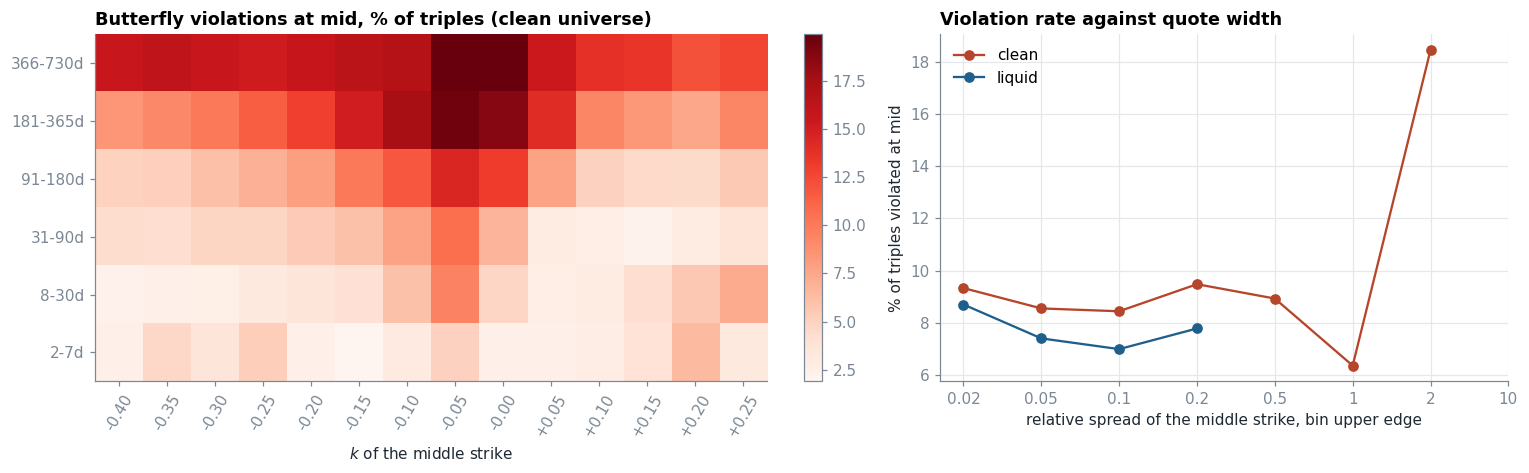

In [27]:
bf = results["clean"]["butterfly"]
bf = bf.assign(k_bin=pd.cut(bf["k"], k_edges), dte_bin=pd.cut(bf["dte"], dte_edges, right=False))
rate = bf.pivot_table(index="dte_bin", columns="k_bin", values="mid_violation", aggfunc="mean", observed=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw={"width_ratios": [1.3, 1]})
im = ax[0].imshow(100 * rate.to_numpy(), aspect="auto", cmap="Reds", origin="lower")
ax[0].set_xticks(range(len(rate.columns)))
ax[0].set_xticklabels([f"{iv.left:+.2f}" for iv in rate.columns], rotation=60)
ax[0].set_yticks(range(len(rate.index)))
ax[0].set_yticklabels([f"{int(iv.left)}-{int(iv.right) - 1}d" for iv in rate.index])
ax[0].set_xlabel("$k$ of the middle strike")
ax[0].set_title("Butterfly violations at mid, % of triples (clean universe)")
ax[0].grid(False)
fig.colorbar(im, ax=ax[0], fraction=0.04)

bf_liq = results["liquid"]["butterfly"]
for frame, label, color in ((results["clean"]["butterfly"], "clean", PUT_C), (bf_liq, "liquid", CALL_C)):
    by_spread = frame.groupby(pd.cut(frame["rel_spread"], [0, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 10]), observed=False)["mid_violation"].mean()
    ax[1].plot(range(len(by_spread)), 100 * by_spread.to_numpy(), marker="o", color=color, label=label)
    ax[1].set_xticks(range(len(by_spread)))
    ax[1].set_xticklabels([f"{iv.right:g}" for iv in by_spread.index])
ax[1].set_xlabel("relative spread of the middle strike, bin upper edge")
ax[1].set_ylabel("% of triples violated at mid")
ax[1].set_title("Violation rate against quote width")
ax[1].legend()
plt.tight_layout()
plt.show()

In [28]:
bf_c = results["clean"]["butterfly"]
bins = pd.cut(bf_c["rel_spread"], [0, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 10])
by_sp = bf_c.groupby(bins, observed=True)["mid_violation"].mean()
hot = rate.stack().idxmax()
box(f"""**What this shows.** Butterfly violations are not spread evenly over the surface. The highest rate is in the
{hot[0]} days bucket at moneyness {hot[1]} ({100 * rate.stack().max():.1f}% of triples). The right panel gives the reason: the
violation rate is {100 * by_sp.iloc[0]:.2f}% when the middle strike's spread is under {by_sp.index[0].right:g} of mid and
{100 * by_sp.iloc[-1]:.2f}% when it is above {by_sp.index[-1].left:g}. The wider the quote, the less the midpoint means.""")

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**What this shows.** Butterfly violations are not spread evenly over the surface. The highest rate is in the
[366, 731) days bucket at moneyness (-0.0, 0.05] (19.9% of triples). The right panel gives the reason: the
violation rate is 9.33% when the middle strike's spread is under 0.02 of mid and
18.47% when it is above 1. The wider the quote, the less the midpoint means.

</div>

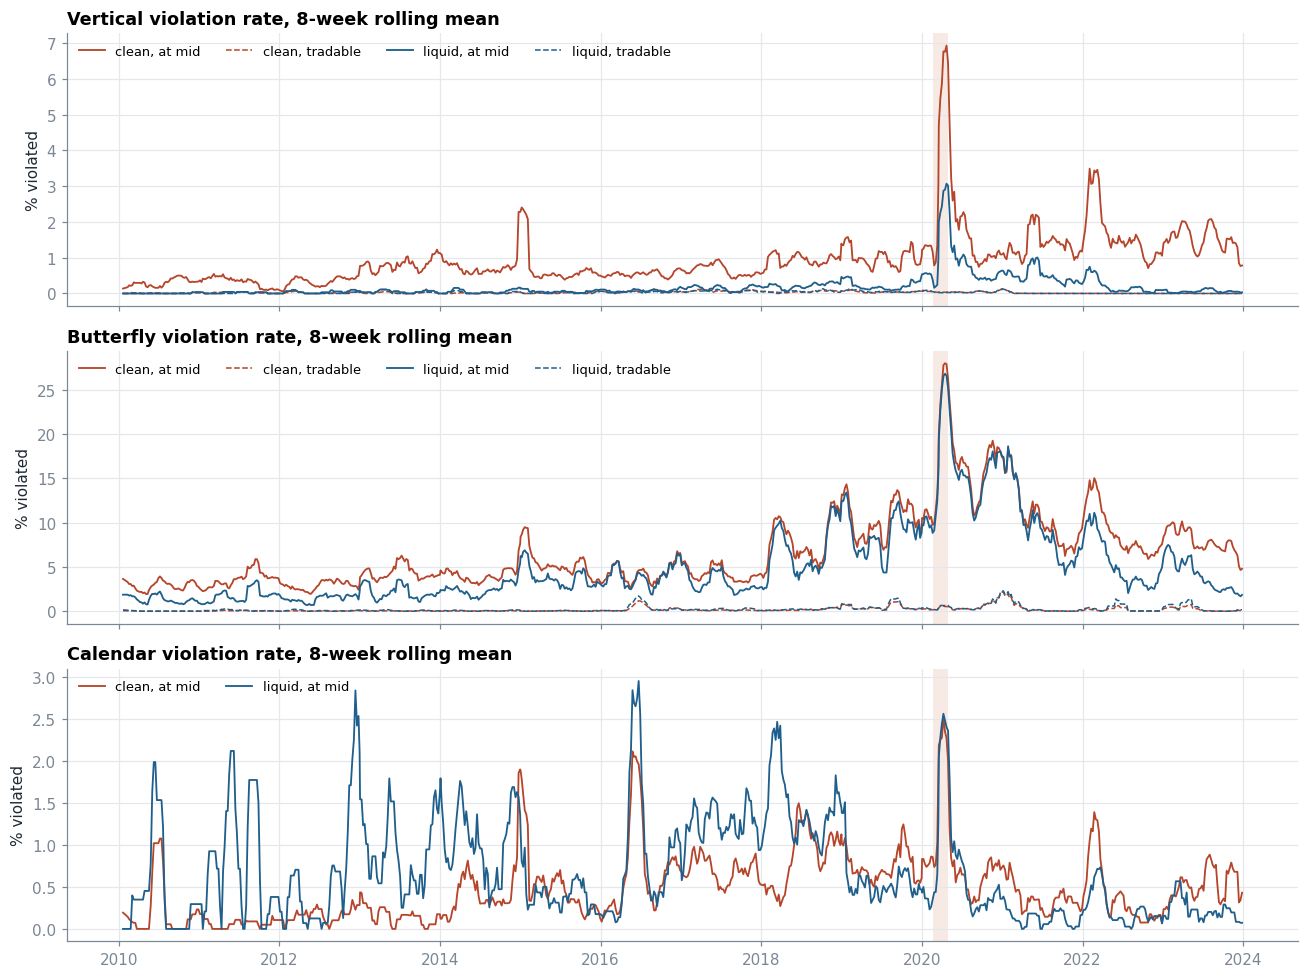

  vertical: mid violation rate, stress window vs rest     5.62% vs 1.09%
  butterfly: mid violation rate, stress window vs rest    25.79% vs 8.19%
  calendar: mid violation rate, stress window vs rest     1.98% vs 0.51%


In [29]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, test in zip(axes, ("vertical", "butterfly", "calendar")):
    for universe, color in (("clean", PUT_C), ("liquid", CALL_C)):
        s = results[universe][test].groupby("date")["mid_violation"].mean().sort_index()
        ax.plot(s.index, 100 * s.rolling(8, min_periods=3).mean(), color=color, lw=1.2, label=f"{universe}, at mid")
        if test != "calendar":
            s2 = results[universe][test].groupby("date")["tradable_violation"].mean().sort_index()
            ax.plot(s2.index, 100 * s2.rolling(8, min_periods=3).mean(), color=color, lw=1, ls="--",
                    label=f"{universe}, tradable")
    shade_stress(ax)
    ax.set_ylabel("% violated")
    ax.set_title(f"{test.capitalize()} violation rate, 8-week rolling mean")
    ax.legend(loc="upper left", ncol=4, fontsize=8.5)
plt.tight_layout()
plt.show()

for test in ("vertical", "butterfly", "calendar"):
    s = results["clean"][test]
    in_stress = s["date"].between(*STRESS_SPAN)
    finding(f"{test}: mid violation rate, stress window vs rest",
            f"{100 * s.loc[in_stress, 'mid_violation'].mean():.2f}% vs {100 * s.loc[~in_stress, 'mid_violation'].mean():.2f}%")

In [30]:
lines, trd = [], {}
for test in ("vertical", "butterfly", "calendar"):
    s = results["clean"][test]
    ins = s["date"].between(*STRESS_SPAN)
    a_, b_ = s.loc[ins, "mid_violation"].mean(), s.loc[~ins, "mid_violation"].mean()
    word = "higher" if a_ > b_ else "lower"
    lines.append(f"- **{test.capitalize()}** at mid: {100 * a_:.2f}% in February-April 2020 against {100 * b_:.2f}% otherwise ({word}).")
    if "tradable_violation" in s:
        trd[test] = (s.loc[ins, "tradable_violation"].mean(), s.loc[~ins, "tradable_violation"].mean())
for test, (a_, b_) in trd.items():
    lines.append(f"- **{test.capitalize()}** at executable prices: {100 * a_:.3f}% in the stress window, {100 * b_:.3f}% otherwise.")
mid_up = any(l.endswith("(higher).") for l in lines)
trd_up = any(a_ > 2 * b_ for a_, b_ in trd.values())
tail = ("Stress raises the rate at mid" if mid_up else "Stress does not raise the rate at mid") + (
    ", and tradable violations rise with it." if trd_up else
    ", while tradable violations do not rise with it: wider quotes create more room for midpoints to disagree, "
    "not more money on the table.")
box("**What this shows.** Violation rates through time, clean universe:\n\n" + "\n".join(lines) + f"\n\n{tail}")

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**What this shows.** Violation rates through time, clean universe:

- **Vertical** at mid: 5.62% in February-April 2020 against 1.09% otherwise (higher).
- **Butterfly** at mid: 25.79% in February-April 2020 against 8.19% otherwise (higher).
- **Calendar** at mid: 1.98% in February-April 2020 against 0.51% otherwise (higher).
- **Vertical** at executable prices: 0.036% in the stress window, 0.025% otherwise.
- **Butterfly** at executable prices: 0.470% in the stress window, 0.231% otherwise.

Stress raises the rate at mid, and tradable violations rise with it.

</div>

In [31]:
top = (results["clean"]["butterfly"].query("tradable_violation")
       .sort_values("credit", ascending=False).head(12)
       .loc[:, ["date", "expiry", "cp", "strike", "dte", "k", "rel_spread", "credit"]])
display(top.assign(date=top["date"].dt.date, expiry=top["expiry"].dt.date).reset_index(drop=True))

tr = results["clean"]["butterfly"].query("tradable_violation")
finding("tradable butterflies (clean universe)", f"{len(tr):,} of {len(results['clean']['butterfly']):,} triples")
finding("of which also in the liquid universe", f"{int(results['liquid']['butterfly']['tradable_violation'].sum()):,}")
finding("median relative spread at the middle strike", f"{tr['rel_spread'].median():.2f}" if len(tr) else "n/a")

,date,expiry,cp,strike,dte,k,rel_spread,credit
0,2015-11-18,2015-12-31,P,204.5,43.00,-0.015623,0.807496,0.340000
1,2020-12-09,2020-12-23,P,365.0,14.00,-0.004279,0.013216,0.330000
2,2020-03-25,2020-04-13,C,256.0,19.00,0.036821,0.019843,0.315000
3,2020-03-25,2020-04-03,C,253.0,9.00,0.028119,0.017133,0.310000
4,2020-03-25,2020-04-03,C,248.0,9.00,0.008158,0.016777,0.276667
5,2020-12-23,2021-01-29,P,367.0,37.00,-0.002586,0.009615,0.273333
6,2020-03-25,2020-04-03,C,250.0,9.00,0.016190,0.015610,0.265000
7,2018-12-31,2019-01-11,P,247.0,11.00,-0.009586,0.021978,0.256667
8,2020-12-23,2021-04-16,P,357.0,113.96,-0.028550,0.005957,0.250000
9,2020-03-25,2020-04-24,C,250.0,30.00,0.014829,0.018078,0.240000


  tradable butterflies (clean universe)                   3,659 of 1,536,810 triples
  of which also in the liquid universe                    2,667
  median relative spread at the middle strike             0.01


In [32]:
bf_all = results["clean"]["butterfly"]
tr = bf_all[bf_all["tradable_violation"]]
n_liq = int(results["liquid"]["butterfly"]["tradable_violation"].sum())
wing_share = (tr["k"].abs() > 0.15).mean() if len(tr) else np.nan
short_share = (tr["dte"] <= 14).mean() if len(tr) else np.nan
box(f"""**Are these arbitrages?** {len(tr):,} butterflies in the clean universe ({100 * len(tr) / max(len(bf_all), 1):.3f}% of
triples) can be put on for a credit at the quoted prices, and {n_liq:,} of them involve only liquid contracts.
{pct(wing_share)} of them sit more than 15% away from the forward and {pct(short_share)} expire within two weeks, and the median
spread at the middle strike is {100 * tr['rel_spread'].median():.0f}% of mid. Three things stand between these rows and a profit:
the quotes are an end-of-day snapshot and need not have been live at the same moment; the displayed size may be a single
contract; and SPY options are American, so the short leg can be exercised early. The honest reading is that these are
**stale or indicative quotes**, and the right use of the list is as a data-quality flag, not as a trading signal.""")

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**Are these arbitrages?** 3,659 butterflies in the clean universe (0.238% of
triples) can be put on for a credit at the quoted prices, and 2,667 of them involve only liquid contracts.
10% of them sit more than 15% away from the forward and 27% expire within two weeks, and the median
spread at the middle strike is 1% of mid. Three things stand between these rows and a profit:
the quotes are an end-of-day snapshot and need not have been live at the same moment; the displayed size may be a single
contract; and SPY options are American, so the short leg can be exercised early. The honest reading is that these are
**stale or indicative quotes**, and the right use of the list is as a data-quality flag, not as a trading signal.

</div>

<a id="svi"></a>
# <p style="padding:10px;background-color:#2c8ae1 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">8. SVI calibration</p>

The raw SVI parameterisation (Gatheral, 2004) describes one expiry's total implied variance as a
function of log-moneyness with five parameters:

$$
w(k) = a + b\left(\rho\,(k - m) + \sqrt{(k - m)^2 + \sigma^2}\right).
$$

$a$ sets the level, $b$ the angle between the wings, $\rho$ the asymmetry (skew), $m$ shifts the smile
horizontally and $\sigma$ controls how rounded the vertex is. Its appeal is that its wings are linear in
$k$, which is what Lee's moment formula says the wings of any arbitrage-free smile must be.

The fit is least squares in total variance on out-of-the-money quotes, with the parameter bounds
$b \ge 0$, $|\rho| < 1$, $\sigma > 0$, and two constraints imposed as penalties:

$$
a + b\,\sigma\sqrt{1 - \rho^2} \;\ge\; 0 \quad \text{(non-negative minimum variance)}, \qquad
b\,(1 + |\rho|) \;\le\; 2 \quad \text{(Lee's bound on the wing slopes)} .
$$

These do not make a fit arbitrage-free on their own. Butterfly freedom of a slice is checked with the
density function of Gatheral and Jacquier (2014), which must be non-negative:

$$
g(k) = \left(1 - \frac{k\,w'}{2w}\right)^2 - \frac{w'^2}{4}\left(\frac{1}{w} + \frac14\right) + \frac{w''}{2} \;\ge\; 0 ,
$$

and calendar freedom by checking that fitted total variance does not fall between consecutive expiries.

Slices: first sampled date of each month plus the three event dates, expiries of 7 to 365 days, at least
eight quotes, $k \in [-0.6, 0.4]$.

In [33]:
def svi_w(k: np.ndarray, p: np.ndarray) -> np.ndarray:
    """Raw SVI total variance w(k) for parameters p = (a, b, rho, m, sigma)."""
    a, b, rho, m, s = p
    return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + s * s))


def svi_g(k: np.ndarray, p: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Gatheral-Jacquier density function g(k) and w(k); butterfly-free iff g >= 0 and w > 0."""
    a, b, rho, m, s = p
    x = k - m
    r = np.sqrt(x * x + s * s)
    w = a + b * (rho * x + r)
    w1 = b * (rho + x / r)
    w2 = b * s * s / r ** 3
    g = (1 - k * w1 / (2 * w)) ** 2 - (w1 ** 2 / 4) * (1 / w + 0.25) + w2 / 2
    return g, w


def fit_svi(k: np.ndarray, w: np.ndarray, rho_starts=(-0.7, -0.3, 0.1)) -> tuple[np.ndarray, float]:
    """Least-squares raw SVI fit with bounds and penalty constraints; returns (params, rmse in w)."""
    wmax = float(w.max())
    lb = np.array([-wmax, 1e-6, -0.999, k.min() - 0.5, 1e-4])
    ub = np.array([wmax, 2.0, 0.999, k.max() + 0.5, 2.0])

    def resid(p: np.ndarray) -> np.ndarray:
        a, b, rho, m, s = p
        pen_min = max(0.0, -(a + b * s * np.sqrt(1 - rho * rho)))
        pen_lee = max(0.0, b * (1 + abs(rho)) - 2.0)
        return np.concatenate([svi_w(k, p) - w, [10 * pen_min, 10 * pen_lee]])

    best = None
    m0 = float(k[np.argmin(w)])
    for rho0 in rho_starts:
        b0, s0 = 0.1, 0.1
        a0 = float(w.min()) - b0 * s0 * np.sqrt(1 - rho0 ** 2)
        x0 = np.clip([a0, b0, rho0, m0, s0], lb + 1e-9, ub - 1e-9)
        sol = least_squares(resid, x0, bounds=(lb, ub), method="trf", max_nfev=400)
        if best is None or sol.cost < best.cost:
            best = sol
    rmse = float(np.sqrt(np.mean((svi_w(k, best.x) - w) ** 2)))
    return best.x, rmse


svi_dates = MONTHLY_DATES.union(pd.DatetimeIndex(list(EVENT_DATES.values())))
svi_set = surf[surf["date"].isin(svi_dates) & surf["dte"].between(7, 365) & surf["k"].between(-0.6, 0.4)]

t = time.time()
fits = []
for (date, expiry), g in svi_set.groupby(["date", "expiry"]):
    if len(g) < 8:
        continue
    k, w, tau = g["k"].to_numpy(), g["w"].to_numpy(), g["tau"].iat[0]
    p, rmse_w = fit_svi(k, w)
    iv_fit = np.sqrt(np.maximum(svi_w(k, p), 1e-12) / tau)
    g_data, w_data = svi_g(np.linspace(k.min(), k.max(), 200), p)
    g_wide, w_wide = svi_g(np.linspace(-1.0, 1.0, 400), p)
    fits.append({
        "date": date, "expiry": expiry, "tau": tau, "dte": g["dte"].iat[0], "n": len(g),
        "a": p[0], "b": p[1], "rho": p[2], "m": p[3], "sigma": p[4],
        "rmse_vp": 100 * np.sqrt(np.mean((iv_fit - g["iv"].to_numpy()) ** 2)),
        "bfly_free_data": bool((g_data >= -1e-10).all() and (w_data > 0).all()),
        "bfly_free_wide": bool((g_wide >= -1e-10).all() and (w_wide > 0).all()),
    })
fits = pd.DataFrame(fits)
finding("SVI slices fitted", f"{len(fits):,} in {time.time() - t:.0f}s")
finding("median / 90th pct RMSE", f"{fits['rmse_vp'].median():.2f} / {fits['rmse_vp'].quantile(0.9):.2f} vol pts")
finding("butterfly-free over the quoted range", f"{100 * fits['bfly_free_data'].mean():.1f}% of slices")
finding("butterfly-free on k in [-1, 1]", f"{100 * fits['bfly_free_wide'].mean():.1f}% of slices")

cal_bad, cal_pairs = 0, 0
for date, g in fits.sort_values("tau").groupby("date"):
    ps = g[["a", "b", "rho", "m", "sigma"]].to_numpy()
    for p1, p2 in zip(ps[:-1], ps[1:]):
        cal_pairs += 1
        cal_bad += bool((svi_w(K_GRID, p2) < svi_w(K_GRID, p1) - 1e-6).any())
finding("consecutive fitted expiries crossing (calendar)", f"{cal_bad:,} of {cal_pairs:,} pairs ({100 * cal_bad / max(cal_pairs, 1):.1f}%)")

  SVI slices fitted                                       3,197 in 559s
  median / 90th pct RMSE                                  0.32 / 0.88 vol pts
  butterfly-free over the quoted range                    99.3% of slices
  butterfly-free on k in [-1, 1]                          34.6% of slices
  consecutive fitted expiries crossing (calendar)         1,421 of 3,028 pairs (46.9%)


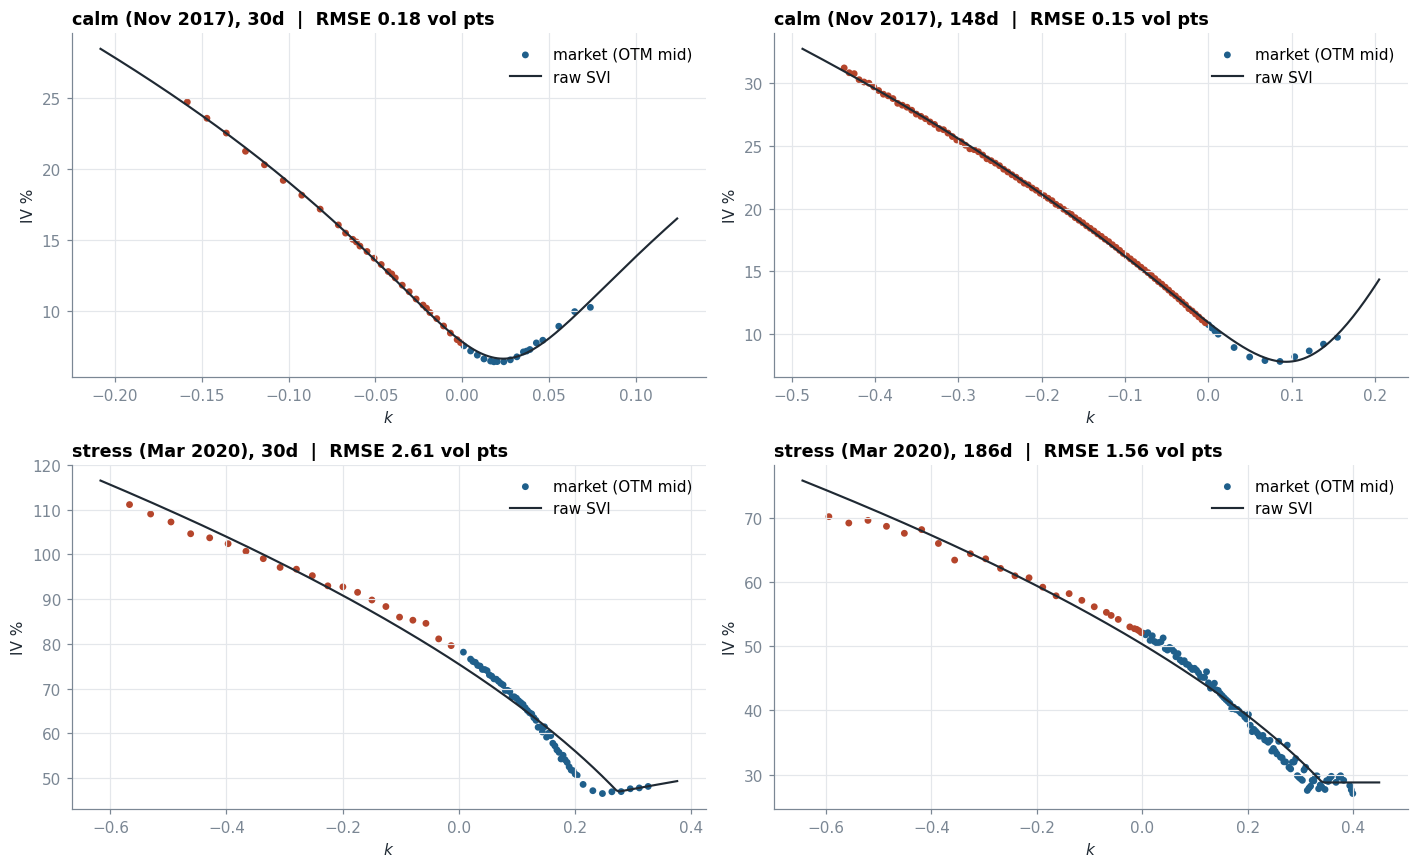

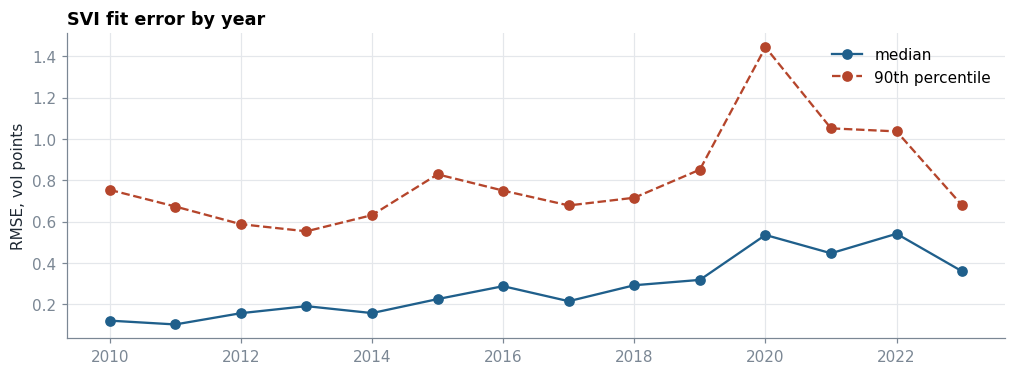

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
panels = []
for name in ("calm (Nov 2017)", "stress (Mar 2020)"):
    d = EVENT_DATES[name]
    day = fits[fits["date"] == d]
    for target in (30, 180):
        if len(day):
            row = day.iloc[np.argmin(np.abs(day["dte"].to_numpy() - target))]
            panels.append((name, row))
for ax, (name, row) in zip(axes.ravel(), panels):
    pts = svi_set[(svi_set["date"] == row["date"]) & (svi_set["expiry"] == row["expiry"])]
    kk = np.linspace(pts["k"].min() - 0.05, pts["k"].max() + 0.05, 200)
    p = row[["a", "b", "rho", "m", "sigma"]].to_numpy(dtype=float)
    ax.scatter(pts["k"], 100 * pts["iv"], s=12, color=np.where(pts["cp"] == "P", PUT_C, CALL_C), label="market (OTM mid)")
    ax.plot(kk, 100 * np.sqrt(np.maximum(svi_w(kk, p), 0) / row["tau"]), color=INK, lw=1.4, label="raw SVI")
    ax.set_title(f"{name}, {int(row['dte'])}d  |  RMSE {row['rmse_vp']:.2f} vol pts")
    ax.set_xlabel("$k$")
    ax.set_ylabel("IV %")
    ax.legend()
plt.tight_layout()
plt.show()

by_year = fits.groupby(fits["date"].dt.year)["rmse_vp"].describe(percentiles=[0.5, 0.9])
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(by_year.index, by_year["50%"], marker="o", label="median")
ax.plot(by_year.index, by_year["90%"], marker="o", ls="--", label="90th percentile")
ax.set_ylabel("RMSE, vol points")
ax.set_title("SVI fit error by year")
ax.legend()
plt.show()

In [35]:
box(f"""**What this shows.** Raw SVI fits a single expiry with a median error of {fits['rmse_vp'].median():.2f} vol points
(90th percentile {fits['rmse_vp'].quantile(0.9):.2f}) across {len(fits):,} slices. {pct(fits['bfly_free_data'].mean())} of fitted
slices are free of butterfly arbitrage over the strikes actually quoted, but only {pct(fits['bfly_free_wide'].mean())} over
$k \\in [-1, 1]$: the fit behaves where there is data and can misbehave in the extrapolated wings. Between consecutive
expiries, {cal_bad:,} of {cal_pairs:,} fitted pairs cross ({pct(cal_bad / max(cal_pairs, 1))}), because each slice is fitted
on its own. A production surface would fit all expiries jointly with calendar constraints (for example SSVI).""")

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**What this shows.** Raw SVI fits a single expiry with a median error of 0.32 vol points
(90th percentile 0.88) across 3,197 slices. 99% of fitted
slices are free of butterfly arbitrage over the strikes actually quoted, but only 35% over
$k \in [-1, 1]$: the fit behaves where there is data and can misbehave in the extrapolated wings. Between consecutive
expiries, 1,421 of 3,028 fitted pairs cross (47%), because each slice is fitted
on its own. A production surface would fit all expiries jointly with calendar constraints (for example SSVI).

</div>

<a id="ml"></a>
# <p style="padding:10px;background-color:#2c8ae1 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">9. Gradient boosting against SVI</p>

### <p style="padding:6px 14px;background-color:#e8f1fb;border-left:6px solid #2c8ae1;margin:0;color:#1f3a5f;font-weight:600">Making the comparison fair</p>

A per-slice SVI fit and a model trained on 2010-2019 are not answering the same question by default.
SVI fitted to a day's quotes is **interpolation** on that day; a model trained on the past and asked for
a volatility is **extrapolation** across time. Comparing their errors directly would flatter SVI for the
wrong reason.

So both are given the same task: for every expiry slice, 20% of the out-of-the-money quotes are hidden
(never the two outermost strikes, so the task stays interpolation), and each method predicts the hidden
implied volatilities.

| method | what it sees |
|---|---|
| linear interpolation | the visible quotes of the same slice |
| **raw SVI** | the visible quotes of the same slice (fitted as in section 8) |
| boosting A | only contract-level features: $k$, $T$, spread, volume, quote size, realised vol, weekday |
| boosting B | A, plus two numbers from the visible quotes: the slice's ATM vol and its skew; it predicts the deviation from that ATM vol |

Model A is the specification as first written. It will struggle for a structural reason: nothing in its
features says where the level of volatility is on the day. Model B is the fair version: it receives the
same-day information SVI receives, compressed into two summary numbers, and has to learn the *shape*.
B's target is $\sigma - \sigma_{\text{ATM}}$ rather than $\sigma$ itself, because a tree ensemble can only
output values inside the range of its training targets, and the volatility levels of March 2020 lie
outside anything seen in 2010-2019.

### <p style="padding:6px 14px;background-color:#e8f1fb;border-left:6px solid #2c8ae1;margin:0;color:#1f3a5f;font-weight:600">Why the split is by time</p>

Training runs on 2010-2019 (with 2019 held back for early stopping) and testing on 2020-2023. A random
split would place neighbouring strikes of the same slice, and the same day's other expiries, on both
sides of the split. Those quotes are almost copies of each other, so a random split measures memory,
not skill. It would also let 2020 information leak into a model evaluated on 2020.

Training rows: hidden quotes from the weekly sample, 2010-2019. Test rows: hidden quotes from the first
sampled date of each month, 2020-2023.

In [36]:
def holdout_flags(k: np.ndarray, frac: float, rng: np.random.Generator) -> np.ndarray:
    """Pick ~frac of interior points (never the two outermost k) as held out."""
    n = len(k)
    order = np.argsort(k)
    interior = order[1:-1]
    m = max(2, int(round(frac * n)))
    flags = np.zeros(n, dtype=bool)
    flags[rng.choice(interior, size=min(m, len(interior)), replace=False)] = True
    return flags


def slice_features(k: np.ndarray, iv: np.ndarray) -> tuple[float, float]:
    """ATM vol (interpolated at k=0) and near-the-money skew d(IV)/dk from the visible quotes."""
    o = np.argsort(k)
    k, iv = k[o], iv[o]
    atm_iv = float(np.interp(0.0, k, iv))
    near = np.abs(k) <= 0.10
    kk, vv = (k[near], iv[near]) if near.sum() >= 3 else (k, iv)
    skew = float(np.polyfit(kk, vv, 1)[0]) if len(kk) >= 2 else np.nan
    return atm_iv, skew


ml_base = surf[surf["dte"].between(7, 365) & surf["k"].between(-0.6, 0.4)].copy()
ml_base = ml_base.merge(rv.rename("rv21"), left_on="date", right_index=True, how="left")
is_train = (ml_base["date"] <= TRAIN_END)
is_test = (ml_base["date"] > TRAIN_END) & ml_base["date"].isin(MONTHLY_DATES)
ml_base = ml_base[is_train | is_test]

rng = np.random.default_rng(SEED)
parts = []
t = time.time()
for (date, expiry), g in ml_base.groupby(["date", "expiry"]):
    if len(g) < 10:
        continue
    k, iv = g["k"].to_numpy(), g["iv"].to_numpy()
    hold = holdout_flags(k, 0.20, rng)
    vis_k, vis_iv = k[~hold], iv[~hold]
    atm_iv, skew = slice_features(vis_k, vis_iv)
    out = g.loc[hold].copy()
    out["atm_iv_vis"], out["skew_vis"] = atm_iv, skew
    o = np.argsort(vis_k)
    out["pred_linear"] = np.interp(out["k"], vis_k[o], vis_iv[o])
    if date > TRAIN_END:
        p, _ = fit_svi(vis_k, vis_iv ** 2 * g["tau"].iat[0])
        out["pred_svi"] = np.sqrt(np.maximum(svi_w(out["k"].to_numpy(), p), 1e-12) / out["tau"])
    parts.append(out)
ml = pd.concat(parts, ignore_index=True)
ml["sqrt_tau"] = np.sqrt(ml["tau"])
ml["log_volume"] = np.log1p(ml["volume"].fillna(0))
ml["log_size"] = np.log1p(ml["bid_size"].fillna(0) + ml["ask_size"].fillna(0))
ml["weekday"] = ml["date"].dt.weekday
ml["is_put"] = (ml["cp"] == "P").astype(int)

FEATS_A = ["k", "tau", "sqrt_tau", "rel_spread", "log_volume", "log_size", "rv21", "weekday", "is_put"]
FEATS_B = FEATS_A + ["atm_iv_vis", "skew_vis"]
train = ml[ml["date"] <= TRAIN_END]
test = ml[ml["date"] > TRAIN_END].copy()
fit_rows = train["date"] < pd.Timestamp("2019-01-01")
finding("held-out rows: train / test", f"{len(train):,} / {len(test):,}  (built in {time.time() - t:.0f}s)")


LGB_PARAMS = {"objective": "regression", "learning_rate": 0.03, "num_leaves": 31, "min_data_in_leaf": 40,
              "bagging_fraction": 0.8, "bagging_freq": 1, "feature_fraction": 0.9,
              "seed": SEED, "deterministic": True, "verbose": -1}


def train_lgbm(features: list, target: pd.Series) -> lgb.Booster:
    """Gradient boosting with early stopping on 2019 (a time-based validation year)."""
    dtrain = lgb.Dataset(train.loc[fit_rows, features], target[fit_rows])
    dval = lgb.Dataset(train.loc[~fit_rows, features], target[~fit_rows], reference=dtrain)
    return lgb.train(LGB_PARAMS, dtrain, num_boost_round=4000, valid_sets=[dval],
                     callbacks=[lgb.early_stopping(150, verbose=False)])


# A learns the level of IV directly. B learns the deviation from the slice's ATM vol: a tree cannot
# output a value outside the range it was trained on, and 2020 volatility lies outside 2010-2019.
model_a = train_lgbm(FEATS_A, train["iv"])
model_b = train_lgbm(FEATS_B, train["iv"] - train["atm_iv_vis"])
test["pred_gbm_a"] = model_a.predict(test[FEATS_A], num_iteration=model_a.best_iteration)
test["pred_gbm_b"] = test["atm_iv_vis"] + model_b.predict(test[FEATS_B], num_iteration=model_b.best_iteration)
finding("boosting rounds kept (A / B)", f"{model_a.best_iteration} / {model_b.best_iteration}")

  held-out rows: train / test                             124,664 / 29,418  (built in 139s)
  boosting rounds kept (A / B)                            84 / 3271


/tmp/ipykernel_23/2179110655.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tables[dim] = test.groupby(dim, observed=True).apply(
/tmp/ipykernel_23/2179110655.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tables[dim] = test.groupby(dim, observed=True).apply(
/tmp/ipykernel_23/2179110655.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a fu

,RMSE (vol pts)
linear interpolation,0.217294
raw SVI,0.655533
boosting A (no same-day info),5.901883
boosting B (+ slice ATM & skew),1.708951


,linear interpolation,raw SVI,boosting A (no same-day info),boosting B (+ slice ATM & skew)
|k| bucket,,,,
"(-0.001, 0.05]",0.107597,0.713291,4.674921,0.590531
"(0.05, 0.15]",0.145119,0.709682,4.965991,1.356928
"(0.15, 0.3]",0.233572,0.513867,6.388798,1.945350
"(0.3, 1.0]",0.443415,0.561079,9.237795,3.258791


,linear interpolation,raw SVI,boosting A (no same-day info),boosting B (+ slice ATM & skew)
DTE bucket,,,,
"[7, 31)",0.304782,0.902301,7.023617,2.147357
"[31, 91)",0.127517,0.623393,6.121501,1.725723
"[91, 181)",0.090329,0.368125,5.096298,1.322081
"[181, 366)",0.186990,0.287935,3.964523,1.028225


,linear interpolation,raw SVI,boosting A (no same-day info),boosting B (+ slice ATM & skew)
period,,,,
Feb-Apr 2020,0.308353,1.150318,14.077289,3.636058
rest of 2020-2023,0.211711,0.620491,5.163171,1.550822


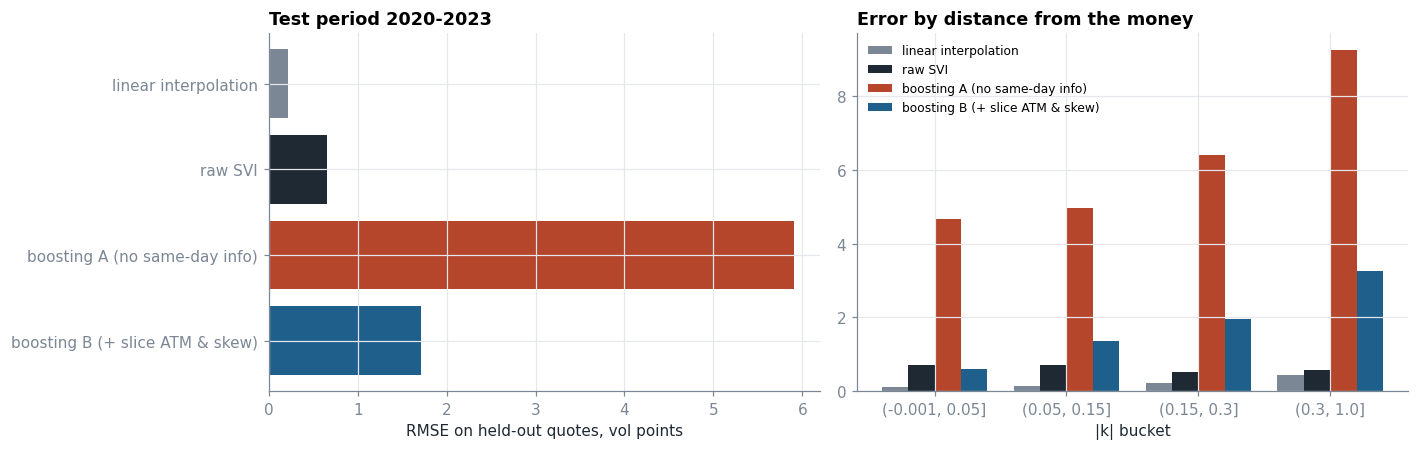

  lowest overall RMSE                                     linear interpolation (0.22 vol pts)
  boosting B minus SVI                                    +1.05 vol pts


In [37]:
MODELS = {"pred_linear": "linear interpolation", "pred_svi": "raw SVI",
          "pred_gbm_a": "boosting A (no same-day info)", "pred_gbm_b": "boosting B (+ slice ATM & skew)"}


def rmse_vp(y: pd.Series, p: pd.Series) -> float:
    """Root-mean-square error in vol points."""
    ok = np.isfinite(y) & np.isfinite(p)
    return float(100 * np.sqrt(np.mean((y[ok] - p[ok]) ** 2)))


test["abs_k"] = pd.cut(test["k"].abs(), [0, 0.05, 0.15, 0.30, 1.0], include_lowest=True)
test["dte_b"] = pd.cut(test["dte"], [7, 31, 91, 181, 366], right=False)
test["period"] = np.where(test["date"].between(*STRESS_SPAN), "Feb-Apr 2020", "rest of 2020-2023")

overall = pd.Series({label: rmse_vp(test["iv"], test[col]) for col, label in MODELS.items()}, name="RMSE (vol pts)")
tables = {}
for dim in ("abs_k", "dte_b", "period"):
    tables[dim] = test.groupby(dim, observed=True).apply(
        lambda g: pd.Series({label: rmse_vp(g["iv"], g[col]) for col, label in MODELS.items()}))
display(overall.to_frame())
display(tables["abs_k"].rename_axis("|k| bucket"))
display(tables["dte_b"].rename_axis("DTE bucket"))
display(tables["period"].rename_axis("period"))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
colors = [MUTED, INK, PUT_C, CALL_C]
ax[0].barh(list(overall.index)[::-1], overall.to_numpy()[::-1], color=colors[::-1])
ax[0].set_xlabel("RMSE on held-out quotes, vol points")
ax[0].set_title("Test period 2020-2023")
tk = tables["abs_k"]
xs = np.arange(len(tk))
for i, (label, color) in enumerate(zip(tk.columns, colors)):
    ax[1].bar(xs + (i - 1.5) * 0.2, tk[label], width=0.2, color=color, label=label)
ax[1].set_xticks(xs)
ax[1].set_xticklabels([str(iv) for iv in tk.index])
ax[1].set_xlabel("|k| bucket")
ax[1].set_title("Error by distance from the money")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

winner = overall.idxmin()
finding("lowest overall RMSE", f"{winner} ({overall.min():.2f} vol pts)")
finding("boosting B minus SVI", f"{overall['boosting B (+ slice ATM & skew)'] - overall['raw SVI']:+.2f} vol pts")

In [38]:
svi_e, gb_e, ga_e, li_e = (overall["raw SVI"], overall["boosting B (+ slice ATM & skew)"],
                           overall["boosting A (no same-day info)"], overall["linear interpolation"])
best = overall.idxmin()
head2head = (f"Between the two models, SVI beats boosting B by {gb_e - svi_e:.2f} vol points" if svi_e <= gb_e
             else f"Between the two models, boosting B beats SVI by {svi_e - gb_e:.2f} vol points")
if best == "linear interpolation":
    verdict = (f"**The simplest method wins.** Linear interpolation between the neighbouring visible quotes scores "
               f"{li_e:.2f} vol points RMSE, against {svi_e:.2f} for raw SVI and {gb_e:.2f} for boosting B. SPY's strikes "
               f"are so densely listed that a hidden quote almost always has close neighbours on both sides. {head2head}.")
elif best == "raw SVI":
    verdict = (f"**Raw SVI wins** at {svi_e:.2f} vol points RMSE, ahead of boosting B ({gb_e:.2f}) and linear "
               f"interpolation ({li_e:.2f}). The model was not tuned further to change that.")
else:
    verdict = (f"**{best} has the lowest error** at {overall.min():.2f} vol points RMSE. {head2head}; "
               f"check the bucket tables before reading much into it.")
closing = ("This is the useful negative result: gradient boosting does not beat the simple and parametric "
           "baselines at filling in a volatility smile. SVI's real advantage is not accuracy at quoted strikes but "
           "a smooth, arbitrage-checkable curve that extends beyond them; machine learning is better spent on what "
           "neither baseline can see." if best != "boosting B (+ slice ATM & skew)" else
           "The margin is what a learned correction on top of the same-day level and skew buys; it is a refinement "
           "of the parametric view rather than a replacement for it.")
box(f"""**The result.** {verdict}

- Model A, which knows nothing about the day it is predicting, is off by {ga_e:.2f} vol points: the level of volatility on
  a given day is information no contract-level feature contains.
- Plain linear interpolation between neighbouring quotes scores {li_e:.2f}, a reminder of how much of this task is
  simply *reading the neighbours*.
- The parametric model carries structure that is true by construction: linear wings, a single smooth minimum and
  variance that cannot go negative. A tree ensemble has to learn that shape from data, and in the wings, where quotes are
  sparse and noisy, there is little to learn from.

{closing}""")

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**The result.** **The simplest method wins.** Linear interpolation between the neighbouring visible quotes scores 0.22 vol points RMSE, against 0.66 for raw SVI and 1.71 for boosting B. SPY's strikes are so densely listed that a hidden quote almost always has close neighbours on both sides. Between the two models, SVI beats boosting B by 1.05 vol points.

- Model A, which knows nothing about the day it is predicting, is off by 5.90 vol points: the level of volatility on
  a given day is information no contract-level feature contains.
- Plain linear interpolation between neighbouring quotes scores 0.22, a reminder of how much of this task is
  simply *reading the neighbours*.
- The parametric model carries structure that is true by construction: linear wings, a single smooth minimum and
  variance that cannot go negative. A tree ensemble has to learn that shape from data, and in the wings, where quotes are
  sparse and noisy, there is little to learn from.

This is the useful negative result: gradient boosting does not beat the simple and parametric baselines at filling in a volatility smile. SVI's real advantage is not accuracy at quoted strikes but a smooth, arbitrage-checkable curve that extends beyond them; machine learning is better spent on what neither baseline can see.

</div>

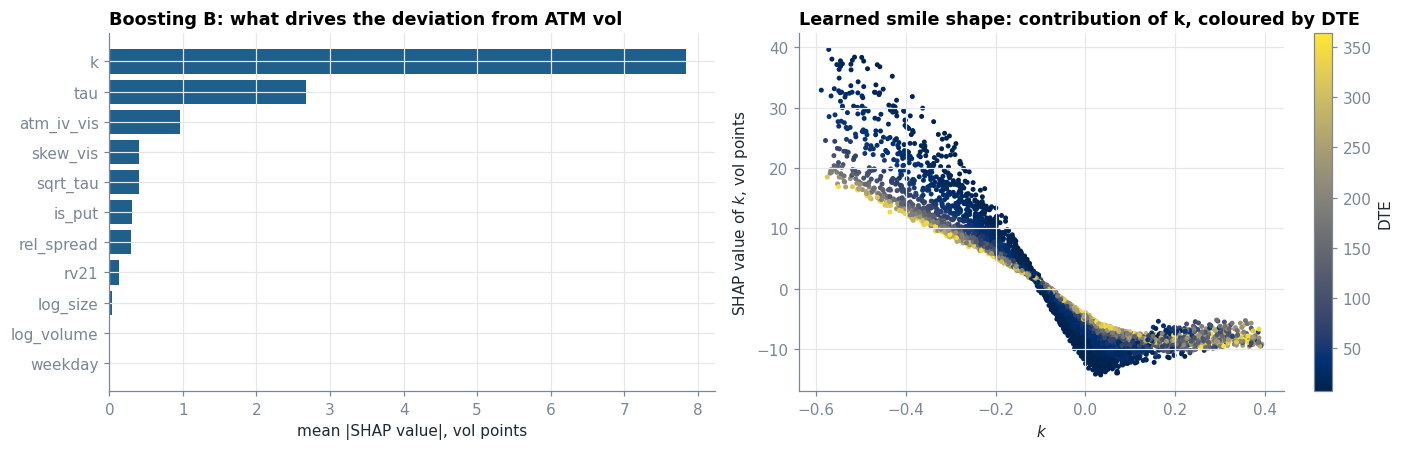

In [39]:
sample = test.sample(min(6000, len(test)), random_state=SEED)
contrib = model_b.predict(sample[FEATS_B], num_iteration=model_b.best_iteration,
                          pred_contrib=True)[:, :-1]   # TreeSHAP values; last column is the bias
imp = pd.Series(np.abs(contrib).mean(axis=0), index=FEATS_B).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].barh(imp.index, 100 * imp.to_numpy(), color=CALL_C)
ax[0].set_xlabel("mean |SHAP value|, vol points")
ax[0].set_title("Boosting B: what drives the deviation from ATM vol")
j = FEATS_B.index("k")
sc = ax[1].scatter(sample["k"], 100 * contrib[:, j], c=sample["dte"], s=5, cmap="cividis")
ax[1].set_xlabel("$k$")
ax[1].set_ylabel("SHAP value of $k$, vol points")
ax[1].set_title("Learned smile shape: contribution of k, coloured by DTE")
fig.colorbar(sc, ax=ax[1], label="DTE")
plt.tight_layout()
plt.show()

In [40]:
top3 = list(imp.sort_values(ascending=False).index[:3])
ck = contrib[:, FEATS_B.index("k")]
short, long_ = (sample["dte"] <= 45).to_numpy(), (sample["dte"] >= 180).to_numpy()
slope = lambda m: np.polyfit(sample["k"].to_numpy()[m], ck[m], 1)[0] if m.sum() > 20 else np.nan
s_short, s_long = slope(short), slope(long_)
direction = "falls as $k$ rises, i.e. puts are marked up relative to calls" if s_short < 0 else "rises with $k$"
steeper = ("steeper for expiries under 45 days than beyond 180 days" if abs(s_short) > abs(s_long)
           else "not steeper for short expiries than for long ones")
box(f"""**What this shows.** The three features the model relies on most are **{top3[0]}**, **{top3[1]}** and **{top3[2]}**.
The right panel isolates the contribution of $k$: it {direction}, and the slope is {steeper}
({100 * s_short:.1f} against {100 * s_long:.1f} vol points per unit of $k$). That is the model rediscovering, from data, the
skew and its term structure that SVI encodes directly through $\\rho$ and $b$.""")

<div style='border: 3px solid none; background-color: #f2f2f2; padding: 10px'>

**What this shows.** The three features the model relies on most are **k**, **tau** and **atm_iv_vis**.
The right panel isolates the contribution of $k$: it falls as $k$ rises, i.e. puts are marked up relative to calls, and the slope is steeper for expiries under 45 days than beyond 180 days
(-70.1 against -34.2 vol points per unit of $k$). That is the model rediscovering, from data, the
skew and its term structure that SVI encodes directly through $\rho$ and $b$.

</div>

<a id="export"></a>
# <p style="padding:10px;background-color:#2c8ae1 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Outputs for reuse</p>

The expensive parts of this notebook, cleaning 14 years of raw quotes, backing out forwards and
re-solving implied volatility, are saved as files so that nobody has to repeat them. To use them in
another notebook: *Add Input -> Notebooks -> Beyond Black-Scholes*, then read the files below.

| file | contents |
|---|---|
| `spy_otm_iv_surface.parquet` | every clean out-of-the-money quote on the sampled dates: date, expiry, strike, forward, discount factor, log-moneyness, bid/ask/mid, re-solved IV, total variance, liquidity flag |
| `forwards_discount_factors.csv` | forward and discount factor per (date, expiry), the rate used, the implied dividend carry, and how the forward was obtained |
| `svi_params.csv` | raw SVI parameters per fitted slice, fit error, butterfly-freedom flags |
| `atm30_iv_weekly.csv` | constant-maturity 30-day ATM implied volatility, weekly |
| `arbitrage_rates_by_date.csv` | violation rates per date for each test, clean and liquid, at mid and executable prices |

The functions are written to be lifted as they are: `implied_vol` (vectorised Newton with bisection
fallback), `implied_forwards` (parity regression), `vertical_checks` / `butterfly_checks` /
`calendar_checks` (static arbitrage on any option chain in long format), `fit_svi` and `svi_g`
(calibration and the butterfly test). None of them depend on SPY.

In [41]:
OUT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
OUT.mkdir(exist_ok=True)
cols = ["date", "expiry", "dte", "tau", "cp", "strike", "spot", "F", "D", "k", "bid", "ask", "mid", "iv", "w", "liquid"]
surf[cols].to_parquet(OUT / "spy_otm_iv_surface.parquet", index=False)
fwd.to_csv(OUT / "forwards_discount_factors.csv", index=False)
fits.to_csv(OUT / "svi_params.csv", index=False)
atm30.rename("atm30_iv").rename_axis("date").to_csv(OUT / "atm30_iv_weekly.csv")
rates = []
for universe, tests in results.items():
    for test, r in tests.items():
        g = r.groupby("date")
        part = g["mid_violation"].mean().rename("mid").to_frame()
        if "tradable_violation" in r:
            part["tradable"] = g["tradable_violation"].mean()
        part["test"], part["universe"] = test, universe
        rates.append(part.reset_index())
pd.concat(rates, ignore_index=True).to_csv(OUT / "arbitrage_rates_by_date.csv", index=False)
for f in sorted(OUT.glob("*.*")):
    if f.suffix in (".parquet", ".csv"):
        finding(f.name, f"{f.stat().st_size / 1e6:.1f} MB")

  arbitrage_rates_by_date.csv                             0.3 MB
  atm30_iv_weekly.csv                                     0.0 MB
  forwards_discount_factors.csv                           2.4 MB
  spy_otm_iv_surface.parquet                              47.6 MB
  svi_params.csv                                          0.6 MB


<a id="conclusion"></a>
# <p style="padding:10px;background-color:#2c8ae1 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">10. What a market maker would do with this</p>

- **Build the surface from the liquid subset only**, and mark everything else to it. The audit shows how
  small that subset is and the arbitrage section shows that the rest carries most of the inconsistency.
- **Treat a mid-price violation as a data flag, not a trade.** Crossing the spread is the test; a quote
  that fails it is stale or indicative, and the right response is to widen or pull the quote, not to
  trade against it.
- **Fit a constrained parametric smile per expiry** and check it for butterfly and calendar arbitrage
  before publishing it. Where raw SVI fails those checks, the fix is a constrained fit (or a surface-wide
  parameterisation such as SSVI), not a more flexible model.
- **Use learned models for what they are good at**: second-order structure on top of the parametric
  surface (wing adjustments by liquidity, event premia), rather than as a replacement for it.
- **Watch the calendar condition around events.** The time series in section 7 is the kind of monitor a
  desk runs intraday: a jump in violations is usually a sign of a quote-feed problem or an event premium
  being priced into one expiry.

<a id="limits"></a>
# <p style="padding:10px;background-color:#2c8ae1 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">11. Limitations and assumptions</p>

- **American exercise.** SPY options are American. Black's formula is European. Using only
  out-of-the-money contracts keeps the early-exercise premium small but not zero, most notably for puts
  when rates are high (2023) and for calls just before an ex-dividend date. Put-call parity is an
  inequality for American options, so the implied forwards carry a small bias.
- **Discrete dividends.** The forward from parity absorbs the dividends paid before each expiry. That is
  exact for the forward but the resulting "carry" $q$ is an average, not a dividend forecast.
- **Rates.** The discount factor uses the annual average 3-month T-bill yield as a proxy, one number per
  year. In 2022, when rates rose from near zero to over 4% within the year, this is coarse; it affects
  discounting only, not the forward, which comes from at-the-money parity.
- **End-of-day snapshots.** Option quotes and the underlying's last print need not be simultaneous; a
  small timing gap moves the forward and shows up as noise in near-the-money volatilities.
- **Filters shape the result.** The liquid universe is defined by thresholds (20% spread, non-zero
  volume). Different thresholds change the violation rates; the direction of the conclusion is what
  matters, not the second decimal.
- **Sampling.** Weekly dates for the full-period statistics and monthly dates for SVI and the model
  comparison. Rare one-day dislocations between sampled dates are not seen.
- **No open interest.** The dataset has none, so liquidity is proxied by volume and quote width.
- **Vendor fields.** The vendor's IV and Greeks are used only for comparison; their method is unknown.

<a id="refs"></a>
# <p style="padding:10px;background-color:#2c8ae1 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">12. References</p>

- Black, F. and Scholes, M. (1973). The pricing of options and corporate liabilities. *Journal of Political Economy*, 81(3), 637-654.
- Black, F. (1976). The pricing of commodity contracts. *Journal of Financial Economics*, 3(1-2), 167-179.
- Carr, P. and Madan, D. B. (2005). A note on sufficient conditions for no arbitrage. *Finance Research Letters*, 2(3), 125-130.
- Gatheral, J. (2004). A parsimonious arbitrage-free implied volatility parameterization with application to the valuation of volatility derivatives. Presentation, Global Derivatives & Risk Management, Madrid.
- Gatheral, J. (2006). *The Volatility Surface: A Practitioner's Guide*. Wiley.
- Gatheral, J. and Jacquier, A. (2014). Arbitrage-free SVI volatility surfaces. *Quantitative Finance*, 14(1), 59-71.
- Lee, R. W. (2004). The moment formula for implied volatility at extreme strikes. *Mathematical Finance*, 14(3), 469-480.
- Roper, M. (2010). Arbitrage free implied volatility surfaces. Working paper, School of Mathematics and Statistics, University of Sydney.
- Ke, G. et al. (2017). LightGBM: a highly efficient gradient boosting decision tree. *Advances in Neural Information Processing Systems 30*.
- Lundberg, S. M. and Lee, S.-I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems 30*.